## Instacart Data Analytics

### Introduction
Instacart is the leading technology and enablement partner for the grocery industry -- helping consumers save time, retailers run their businesses online and in-store, and connects brands with customers. [Instacart 4/09/2026 annual report]

### Data
[Instacart datasets](https://www.kaggle.com/datasets/psparks/instacart-market-basket-analysis/data?select=orders.csv) were obtained from Kaggle. This dataset was originally a Kaggle competition hosted by Instacart in 2017. Since I'm not using this project for competition purposes, I opted to use selected datasets. These datasets and fields are:

aisles:
- aisle_id: unique aisle id
- aisle: unique aisle description (e.g., packaged meat, fresh pasta)

departments
- department_id: unique department id
- department: unique department description (e.g., frozen, produce)

order_products__prior (each row at per order per product grain)
- order_id: unique order id
- product_id: foreign key from products table
- add_to_cart_order: sequential order in which each item was added to a user's cart during a single check-out session
- reordered: 0 represents first-time purchase; 1 represents repeated buy

orders (each row at per order grain)
- order_id: unique order id
- user_id
- eval_set: labels each row as prior, train, or test. For this project, I only use prior data.
- order_number: chronological rank of each order pertaining to a specific user
- order_dow: values range between 0 and 6. Not officially specified, but community consensus is that 0 represents Saturday and 1 represents Sunday, and so on given the spike on Day 0 and Day 1, followed by steady drop-off, and the assumption that people tend to have more free time on the weekends to meal-prep and restock.
- order_hour_of_day: values range between 0 and 23, with 0 representing midnight and 23 representing 11:00pm.
- days_since_prior_order: number of days since last order

products
- product_id: unique product id
- product_name: product description
- aisle_id: foreign key from aisles table
- department_id: foreign key from departments table

### Business Objective
Two main KPIs that Instacart uses to measure the health of their business are:
1. Orders - the volume metric
2. Gross Transaction Value (GTV) - the money metric

Orders measures scale, engagement, and adoption. Increasing orders indicate successful acquisition of new customers and continuing engagement of existing ones.

GTV measures the total economic activity flowing through Instacart's ecosystem, including retailer fees, customer fees, and advertising. Among the various revenue streams, transaction revenue ($2.7b as of 12/31/2025) accounts for ~73% total revenue ($3.7b as of 12/31/2025). Further, the increase in transaction revenue in 2025 compared to 2024 was primarily driven by growth in GTV, which can be driven by either order volume or basket size; this analysis focuses on the latter.

With increasing basket size as the main goal, we propose (a) personalized sponsored product ads based on customers' preferences; and (b) cart-based suggestions.

Personalized sponsored product ads sit at the top of the funnel, as they leave impression when consumers sign into their Instacart accounts and browse stores. 

In comparison, cart-based suggestions sit at the bottom of the funnel, where they serve as recommendations or reminders during customers' check-out.

Together, these two surfaces cover the full purchase funnel: discovery during browsing and incremental additions at checkout.

Note: Sections 4-6 (clustering, stability, profiling) develop a customer segmentation that informs strategy (a) personalized sponsored ads. Section 7 (association rules) supports strategy (b) cart-based suggestions.

### Limitations
The Instacart datasets contain notable constraints for our analysis, including missing product prices, retailers, and customers' demographic information (region of residence, property type, age, device type). 

The cluster interpretation could be substantially enriched with demographic data by distinguishing whether the high-organic segment represents health-conscious shoppers, higher-income households, or families with specific lifestyle priorities. Price data would similarly help disambiguate preference from price sensitivity as the underlying driver of organic vs conventional choices.

The association rules are currently mined at the product-name level. With brand data, recommendations could be elevated to brand-level affinity, which is more directly actionable for sponsored-ad placement. Price data would also enable weighting rules by transaction value, prioritizing high-margin complements over merely frequent ones.

However, given the constraints, we are unable to cluster consumers based on their socioeconomic baseline or infer their price sensitivity. As a result, for our clustering purposes, we could only leverage on organic product shares in each order for the selected departments, which we believe to differentiate consumers based on their organic preference.

### Outline
1. Data validation - validates data integrity, evaluates the impacts of dropping records with missing labels
2. Distributions - finds top departments and examines organic purchase ratio distribution per department
3. Correlation - examines correlations among departments to select distinct department features
4. GMM Clustering - fits Gaussian mixtures across multiple k values and qualitatively examines cluster profiles
5. Cluster Stability Test - fits GMM models 50 times using bootstrapped samples (without replacement) and quantitatively analyzes k cluster size using ARI. Selects the final cluster size on both qualitative and quantitative ground.
6. Cluster Profiling - identifies that clusters differentiate primarily on organic preference but not on shopping cadence or basket size
7. Association Rules - mines product associations and discovers that the product pairs tend to be recipe-driven or pantry staples

### 1. Data Validation

First, we merge the datasets (aisles, departments, order_products__prior, orders, products) to create a flat table.

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text

In [4]:
# Load datasets
order_products = pd.read_csv("Data/order_products__prior.csv")
orders = pd.read_csv("Data/orders.csv")
products = pd.read_csv("Data/products.csv")
aisles = pd.read_csv("Data/aisles.csv")
departments = pd.read_csv("Data/departments.csv")

In [5]:
order_products["reordered"].unique()

array([1, 0])

We validated that reordered column contains only 0 and 1 as expected. This field supports retention/habit analyses, which fall outside this project's basket-size focus, so we don't use it downstream.

In [6]:
# Merge all the datasets
merged_df = (
    order_products.merge(products, on="product_id", how="left")
    .merge(aisles, on="aisle_id", how="left")
    .merge(departments, on="department_id", how="left")
    .merge(orders, on="order_id", how="left")
    .drop(columns=["eval_set"])
)

In [7]:
pd.set_option("display.float_format", lambda x: "%.3f" % x)
merged_df.describe()

,order_id,product_id,add_to_cart_order,reordered,aisle_id,department_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,32434489.000,32434489.000,32434489.000,32434489.000,32434489.000,32434489.000,32434489.000,32434489.000,32434489.000,32434489.000,30356421.000
mean,1710748.519,25576.338,8.351,0.590,71.214,9.922,102937.239,17.142,2.739,13.425,11.104
std,987300.696,14096.689,7.127,0.492,38.203,6.281,59466.478,17.535,2.090,4.246,8.779
min,2.000,1.000,1.000,0.000,1.000,1.000,1.000,1.000,0.000,0.000,0.000
25%,855943.000,13530.000,3.000,0.000,31.000,4.000,51421.000,5.000,1.000,10.000,5.000
50%,1711048.000,25256.000,6.000,1.000,83.000,9.000,102611.000,11.000,3.000,13.000,8.000
75%,2565514.000,37935.000,11.000,1.000,107.000,16.000,154391.000,24.000,5.000,16.000,15.000
max,3421083.000,49688.000,145.000,1.000,134.000,21.000,206209.000,99.000,6.000,23.000,30.000


Since most of the columns are unique identifiers (e.g., order_id, user_id) or categorical values (e.g., reordered, order_dow), the stats per se aren't meaningful. However, it ensures that there don't exist unexpected values such as negative values.

In [77]:
print(
    f'There are no duplicate aisle labels: {aisles.shape[0] == aisles["aisle"].nunique()}'
)

There are no duplicate aisle labels: True


In [9]:
# Display all unique aisle labels
aisles["aisle"].unique().tolist()

['prepared soups salads',
 'specialty cheeses',
 'energy granola bars',
 'instant foods',
 'marinades meat preparation',
 'other',
 'packaged meat',
 'bakery desserts',
 'pasta sauce',
 'kitchen supplies',
 'cold flu allergy',
 'fresh pasta',
 'prepared meals',
 'tofu meat alternatives',
 'packaged seafood',
 'fresh herbs',
 'baking ingredients',
 'bulk dried fruits vegetables',
 'oils vinegars',
 'oral hygiene',
 'packaged cheese',
 'hair care',
 'popcorn jerky',
 'fresh fruits',
 'soap',
 'coffee',
 'beers coolers',
 'red wines',
 'honeys syrups nectars',
 'latino foods',
 'refrigerated',
 'packaged produce',
 'kosher foods',
 'frozen meat seafood',
 'poultry counter',
 'butter',
 'ice cream ice',
 'frozen meals',
 'seafood counter',
 'dog food care',
 'cat food care',
 'frozen vegan vegetarian',
 'buns rolls',
 'eye ear care',
 'candy chocolate',
 'mint gum',
 'vitamins supplements',
 'breakfast bars pastries',
 'packaged poultry',
 'fruit vegetable snacks',
 'preserved dips spreads

In [78]:
print(
    f'There are no duplicate department labels: {departments.shape[0] == departments["department"].nunique()}'
)

There are no duplicate department labels: True


In [11]:
# Display all unique department labels
departments["department"].unique()

<StringArray>
[         'frozen',           'other',          'bakery',         'produce',
         'alcohol',   'international',       'beverages',            'pets',
 'dry goods pasta',            'bulk',   'personal care',    'meat seafood',
          'pantry',       'breakfast',    'canned goods',      'dairy eggs',
       'household',          'babies',          'snacks',            'deli',
         'missing']
Length: 21, dtype: str

We confirmed that aisles table contains unique aisle name. Same for departments table where there only exists unique department descriptions. However, both aisles and departments contain "missing" value as description. Let's next take a look at the rows containing these "missing" values.

In [12]:
rows_w_missing_aisle_depart = merged_df.loc[
    (merged_df["aisle"] == "missing") | (merged_df["department"] == "missing")
]
rows_w_missing_aisle_depart.head()

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
629,75,44077,13,0,Tomato Basil Bisque Soup,100,21,missing,missing,106387,1,5,19,NaN
1419,154,41801,3,1,Cold Pressed Watermelon & Lemon Juice Blend,100,21,missing,missing,73310,68,6,19,0.000
1420,154,11806,4,0,Paleo Blueberry Muffin,100,21,missing,missing,73310,68,6,19,0.000
3975,420,7456,4,0,Organic Poblano Pepper,100,21,missing,missing,161762,37,2,11,2.000
4778,501,3884,11,0,Organic Plain Unsweetened Nondairy Cashew Yogurt,100,21,missing,missing,86142,40,2,12,16.000


As we can see, for the products that have aisle and/or department marked as "missing" should have proper labeling. For instance, Organic Poblano Pepper likely belongs to "fresh vegetables" aisle and "produce" department. There are three potential ways to handle these data with "missing" values.
1. First, we can simply exclude all the rows with "missing" aisle and department. However, this approach would corrupt the integrity of the entire orders that these rows pertain to. This is important, as our objective is finding the characteristics of grocers who prefer to shop organics vs non-organics. If organic products are mislabeled at a higher rate than conventional ones, dropping these rows biases our analysis against the signal that we are trying to measure. So this method is not considered, which leaves us with two options.
2. Second, we can drop all orders that contain mislabeled items. But since each order could contain multiple rows, we need to assess the impact on data loss, as it could amount to a significant amount. Further, we need to examine how many users associated with the problem rows are first-time Instacart shoppers. It matters since if we exclude the entire orders, we risk losing some customers if they have placed only one order (as provided in this dataset), which impacts our clustering analysis later on.
3. Third, we can relabel "missing" aisles and departments based on existing values using NLP or certain rules, and this way we can keep all the rows.

Next, let's examine the impact on data loss by checking how many order ids we have in total, and how many are impacted.

In [13]:
impacted_order_ids = rows_w_missing_aisle_depart["order_id"].unique()
print(f'Number of unique order ids = {merged_df["order_id"].nunique()}')
print(
    f"Number of unique order ids affected by purchases containing missing labels = {impacted_order_ids.shape[0]}"
)

Number of unique order ids = 3214874
Number of unique order ids affected by purchases containing missing labels = 59477


There are a total of 3,214,874 unique order ids, and 59,477 are affected by mislabeled aisles and departments. That is ~2% of total orders. However, we also need to assess the impact on data loss at row-level.

In [14]:
all_rows_for_missing_aisle_depart = merged_df[
    merged_df["order_id"].isin(rows_w_missing_aisle_depart["order_id"])
]
all_rows_for_missing_aisle_depart.head()

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
617,75,25138,1,0,Organic Plain Greek Whole Milk Yogurt,120,16,yogurt,dairy eggs,106387,1,5,19,NaN
618,75,2361,2,0,Mint Chip,37,1,ice cream ice,frozen,106387,1,5,19,NaN
619,75,10915,3,0,Organic Short Brown Sprouted Rice,68,10,bulk grains rice dried goods,bulk,106387,1,5,19,NaN
620,75,39275,4,0,Organic Blueberries,123,4,packaged vegetables fruits,produce,106387,1,5,19,NaN
621,75,21616,5,0,Organic Baby Arugula,123,4,packaged vegetables fruits,produce,106387,1,5,19,NaN


In [15]:
print(f"Total number of rows: {merged_df.shape[0]}")
print(
    f"Number of rows affected by missing labels: {all_rows_for_missing_aisle_depart.shape[0]}"
)
print(
    f"Percent of rows affected = {all_rows_for_missing_aisle_depart.shape[0]/merged_df.shape[0]*100:.2f} %"
)

Total number of rows: 32434489
Number of rows affected by missing labels: 942816
Percent of rows affected = 2.91 %


We have 32,434,489 rows in total, and if we were to exclude all orders containing mislabeled aisles and department, we would be excluding 942,816 rows, which accounts for ~3%. This is quite a small percentage. Next, let's examine how many first-time customers we would be excluding.

In [16]:
num_orders_per_user = (
    orders.groupby("user_id")["order_id"].nunique().rename("total_orders")
)
num_orders_per_user.head()

user_id
1    11
2    15
3    13
4     6
5     5
Name: total_orders, dtype: int64

In [17]:
repeated_cust_mask = num_orders_per_user > 1
repeated_cust = num_orders_per_user[repeated_cust_mask].index
repeated_cust

one_time_cust = num_orders_per_user[~repeated_cust_mask].index
one_time_cust

print(f"Number of repeated grocers = {len(repeated_cust)}")
print(f'Number of unique user ids = {orders["user_id"].nunique()}')

Number of repeated grocers = 206209
Number of unique user ids = 206209


Interestingly, we found that there is no customer with only one order history in the datasets, which means our previous concern of losing certain users entirely now becomes "for users we keep, how much of their history do we lose?"

In [18]:
num_missing_labels_per_user = (
    rows_w_missing_aisle_depart.groupby("user_id")["order_id"]
    .nunique()
    .rename("impacted_orders")
)
num_missing_labels_per_user.head()

user_id
11    1
13    5
14    1
29    1
37    1
Name: impacted_orders, dtype: int64

In [19]:
num_total_and_missing_orders = (
    pd.concat([num_orders_per_user, num_missing_labels_per_user], axis=1)
    .fillna(0)
    .astype(int)
)
num_total_and_missing_orders["impact_pct"] = (
    num_total_and_missing_orders["impacted_orders"]
    / num_total_and_missing_orders["total_orders"]
)
num_total_and_missing_orders.describe()

,total_orders,impacted_orders,impact_pct
count,206209.000,206209.000,206209.000
mean,16.590,0.288,0.019
std,16.655,1.078,0.068
min,4.000,0.000,0.000
25%,6.000,0.000,0.000
50%,10.000,0.000,0.000
75%,20.000,0.000,0.000
max,100.000,52.000,0.923


In [20]:
num_total_and_missing_orders.loc[
    num_total_and_missing_orders["impact_pct"] > 0
].describe()

,total_orders,impacted_orders,impact_pct
count,27862.000,27862.000,27862.000
mean,25.279,2.135,0.137
std,21.576,2.159,0.135
min,4.000,1.000,0.010
25%,9.000,1.000,0.047
50%,18.000,1.000,0.091
75%,35.000,2.000,0.180
max,100.000,52.000,0.923


(0.0, 1.0261666840109798)

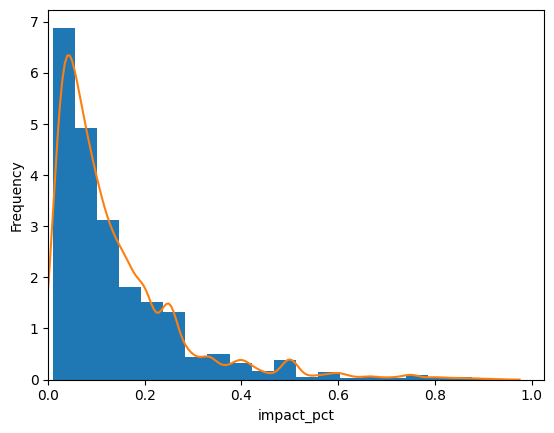

In [21]:
impacted_orders_data = num_total_and_missing_orders["impact_pct"].loc[
    num_total_and_missing_orders["impact_pct"] > 0
]

fig, ax = plt.subplots()
impacted_orders_data.plot.hist(bins=20, density=True)
sns.kdeplot(data=impacted_orders_data, ax=ax)
ax.set_xlim(left=0)

We observed that 27,862 out of 206,209 unique orders are impacted by data loss if we were to exclude orders containing mislabeled aisles and departments, which accounts for ~13.5% of total sample size. Further, among these impacted, median impact percentage is ~9%, which means for every 5 orders that a customer  placed, we lose one order's data. The KDE plot shows right-skewed distribution with the peak between 0.0 and 0.1 range. The risk appears moderate.

We performed a quick check to examine the proportion of organic vs non-organic products with missing labels.

In [22]:
merged_products = products.merge(aisles, on="aisle_id", how="left").merge(
    departments, on="department_id", how="left"
)
merged_products["organic"] = (
    merged_products["product_name"].str.contains("organic", case=False).astype(int)
)

In [23]:
merged_products["is_missing"] = (merged_products["aisle"] == "missing") | (
    merged_products["department"] == "missing"
)
merged_products.head()

,product_id,product_name,aisle_id,department_id,aisle,department,organic,is_missing
0,1,Chocolate Sandwich Cookies,61,19,cookies cakes,snacks,0,False
1,2,All-Seasons Salt,104,13,spices seasonings,pantry,0,False
2,3,Robust Golden Unsweetened Oolong Tea,94,7,tea,beverages,0,False
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,frozen meals,frozen,0,False
4,5,Green Chile Anytime Sauce,5,13,marinades meat preparation,pantry,0,False


In [24]:
organic_vs_missing_data = pd.crosstab(
    merged_products["organic"], merged_products["is_missing"], normalize="index"
)
organic_vs_missing_data

is_missing,False,True
organic,,
0,0.976,0.024
1,0.965,0.035


<Axes: xlabel='organic'>

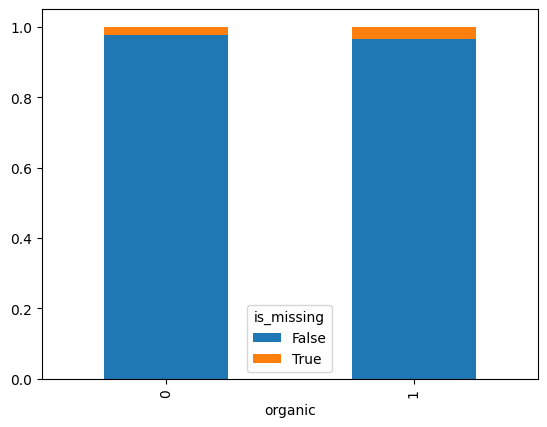

In [25]:
organic_vs_missing_data.plot.bar(stacked=True)

Based on the table and visualization above, we can see that ~3% of both organic and conventional products are affected, though impacted organic portion is marginally higher by ~1%. Given that organic products don't appear to be systematically missing more frequently than conventional products overall, we decide to exclude the orders containing missing labels. 

However, due to missing aisle/department labels, we cannot confirm if among organic products at individual aisle/department level, there exists systematic bias. We will revisit this decision if the clustering reveals anomalies in the impacted user subgroup.

Lastly, we perform a final check to see if there is any other missing data issues.

In [26]:
merged_df.isnull().sum()

order_id                        0
product_id                      0
add_to_cart_order               0
reordered                       0
product_name                    0
aisle_id                        0
department_id                   0
aisle                           0
department                      0
user_id                         0
order_number                    0
order_dow                       0
order_hour_of_day               0
days_since_prior_order    2078068
dtype: int64

In [27]:
merged_df[merged_df["days_since_prior_order"].isnull()]["user_id"].unique()

array([182912, 202527,  52564, ...,  48836, 107102, 117076],
      shape=(206209,))

In [28]:
merged_df.loc[merged_df["user_id"] == 107102].sort_values(
    by=["order_number", "add_to_cart_order"]
)

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
32434442,3421077,27966,1,0,Organic Raspberries,123,4,packaged vegetables fruits,produce,107102,1,3,10,NaN
32434443,3421077,45007,2,0,Organic Zucchini,83,4,fresh vegetables,produce,107102,1,3,10,NaN
32434444,3421077,26940,3,0,Organic Large Green Asparagus,83,4,fresh vegetables,produce,107102,1,3,10,NaN
32434445,3421077,27845,4,0,Organic Whole Milk,84,16,milk,dairy eggs,107102,1,3,10,NaN
8483430,895456,27966,1,1,Organic Raspberries,123,4,packaged vegetables fruits,produce,107102,2,4,7,8.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32348588,3412054,14901,15,1,Raisins,117,19,nuts seeds dried fruit,snacks,107102,33,1,9,5.000
14020352,1479679,13176,1,1,Bag of Organic Bananas,24,4,fresh fruits,produce,107102,34,4,15,3.000
14020353,1479679,39180,2,1,Organic Lowfat 1% Milk,84,16,milk,dairy eggs,107102,34,4,15,3.000
14020354,1479679,11063,3,1,Clover Org Greek Plain,120,16,yogurt,dairy eggs,107102,34,4,15,3.000


We can see that under days_since_prior_order column, there are 2,078,068 missing records. I randomly picked user_id 107102 for closer examination, and we can see that days_since_prior_order is undefined for the first order. We can either leave the null values or replace them with either numeric or categorical values. However, replacing these null values introduces new problems. For example, if we replace these missing values with 0, we are implying that these orders were placed on the same day as their last orders. If we replace with textual values such as "missing", then it's no different from keeping the null values as-is. 

For now, we will leave the NaNs alone.

In [29]:
# Drop rows that contain "missing" aisles and departments
clean_df = merged_df[~merged_df["order_id"].isin(impacted_order_ids)]

### 2. Distributions

In [30]:
clean_df["organic"] = (
    clean_df["product_name"].str.contains("organic", case=False).astype(int)
)
clean_df.head()

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,organic
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs,202279,3,5,9,8.000,1
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce,202279,3,5,9,8.000,1
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry,202279,3,5,9,8.000,0
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry,202279,3,5,9,8.000,0
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry,202279,3,5,9,8.000,0


In [31]:
organic_purchase_pct = (
    clean_df.groupby("department")["organic"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "organic_pct", "count": "total_purchases"})
)

Text(0.5, 0, 'total purchases')

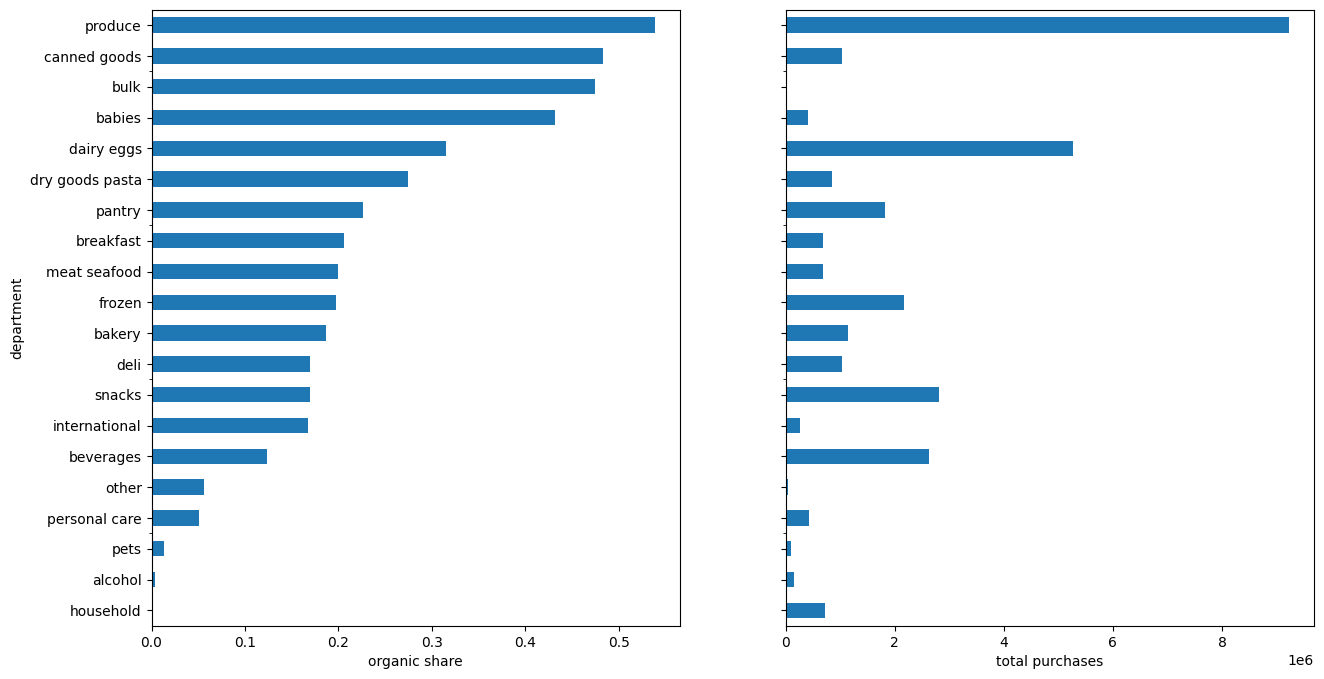

In [32]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(15, 8))
organic_purcahse_pct_sorted = organic_purchase_pct.sort_values("organic_pct")
organic_purcahse_pct_sorted["organic_pct"].plot.barh(ax=axes[0])
organic_purcahse_pct_sorted["total_purchases"].plot.barh(ax=axes[1])
axes[0].set_xlabel("organic share")
axes[1].set_xlabel("total purchases")

The above horizontal bar charts are plotted based on total count of line items per department, rather than physical units. The plot gave us a general idea of which categories see highest percentage of organic product purchases. The top categories are produce, canned goods, bulk, and babies (baby food).

Next, we examine grocers' purchase distribution per department.

In [33]:
user_level_data = (
    clean_df.groupby(["user_id", "department"])["organic"].mean().unstack()
)
user_level_data.head()

department,alcohol,babies,bakery,beverages,breakfast,bulk,canned goods,dairy eggs,deli,dry goods pasta,frozen,household,international,meat seafood,other,pantry,personal care,pets,produce,snacks
user_id,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,0.000,0.000,NaN,NaN,0.923,NaN,NaN,NaN,0.000,NaN,NaN,NaN,0.000,NaN,NaN,0.600,0.000
2,NaN,NaN,0.500,0.222,0.000,NaN,0.000,0.062,0.238,NaN,0.059,NaN,0.333,1.000,NaN,0.636,0.000,NaN,0.556,0.214
3,NaN,NaN,NaN,0.000,NaN,NaN,NaN,0.190,0.000,0.000,0.000,0.000,NaN,NaN,NaN,0.000,NaN,NaN,0.605,0.333
4,0.000,NaN,0.000,0.000,NaN,NaN,0.000,NaN,0.000,NaN,0.000,0.000,NaN,NaN,NaN,NaN,NaN,NaN,1.000,0.000
5,NaN,NaN,NaN,NaN,NaN,NaN,1.000,0.125,0.000,1.000,0.000,NaN,1.000,NaN,NaN,0.500,NaN,NaN,0.632,0.000


In [34]:
counts_per_user = clean_df.groupby(["user_id", "department"]).size().unstack()
counts_per_user.head()

department,alcohol,babies,bakery,beverages,breakfast,bulk,canned goods,dairy eggs,deli,dry goods pasta,frozen,household,international,meat seafood,other,pantry,personal care,pets,produce,snacks
user_id,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,13.000,3.000,NaN,NaN,13.000,NaN,NaN,NaN,2.000,NaN,NaN,NaN,1.000,NaN,NaN,5.000,22.000
2,NaN,NaN,2.000,9.000,3.000,NaN,1.000,48.000,21.000,NaN,17.000,NaN,3.000,1.000,NaN,11.000,1.000,NaN,36.000,42.000
3,NaN,NaN,NaN,3.000,NaN,NaN,NaN,21.000,2.000,4.000,6.000,1.000,NaN,NaN,NaN,4.000,NaN,NaN,38.000,9.000
4,2.000,NaN,2.000,3.000,NaN,NaN,1.000,NaN,2.000,NaN,3.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,2.000,1.000
5,NaN,NaN,NaN,NaN,NaN,NaN,1.000,8.000,1.000,1.000,2.000,NaN,2.000,NaN,NaN,2.000,NaN,NaN,19.000,1.000


To analyze distributions more accurately, we filtered to consumers who placed 5 or more orders. This is because for users with few purchases in a department, we see trimodal distribution patterns, which could be created by binning artifact. Take a consumer who bought 2 items in canned goods for instance, if one is organic and one not, it contributes a value of exactly 0.5, causing the middle peak. However, once we filtered to users with at least 5 purchases, some trimodal distributions disappeared, while those persisted likely indicate real signals, specifically, the babies and produce departments.

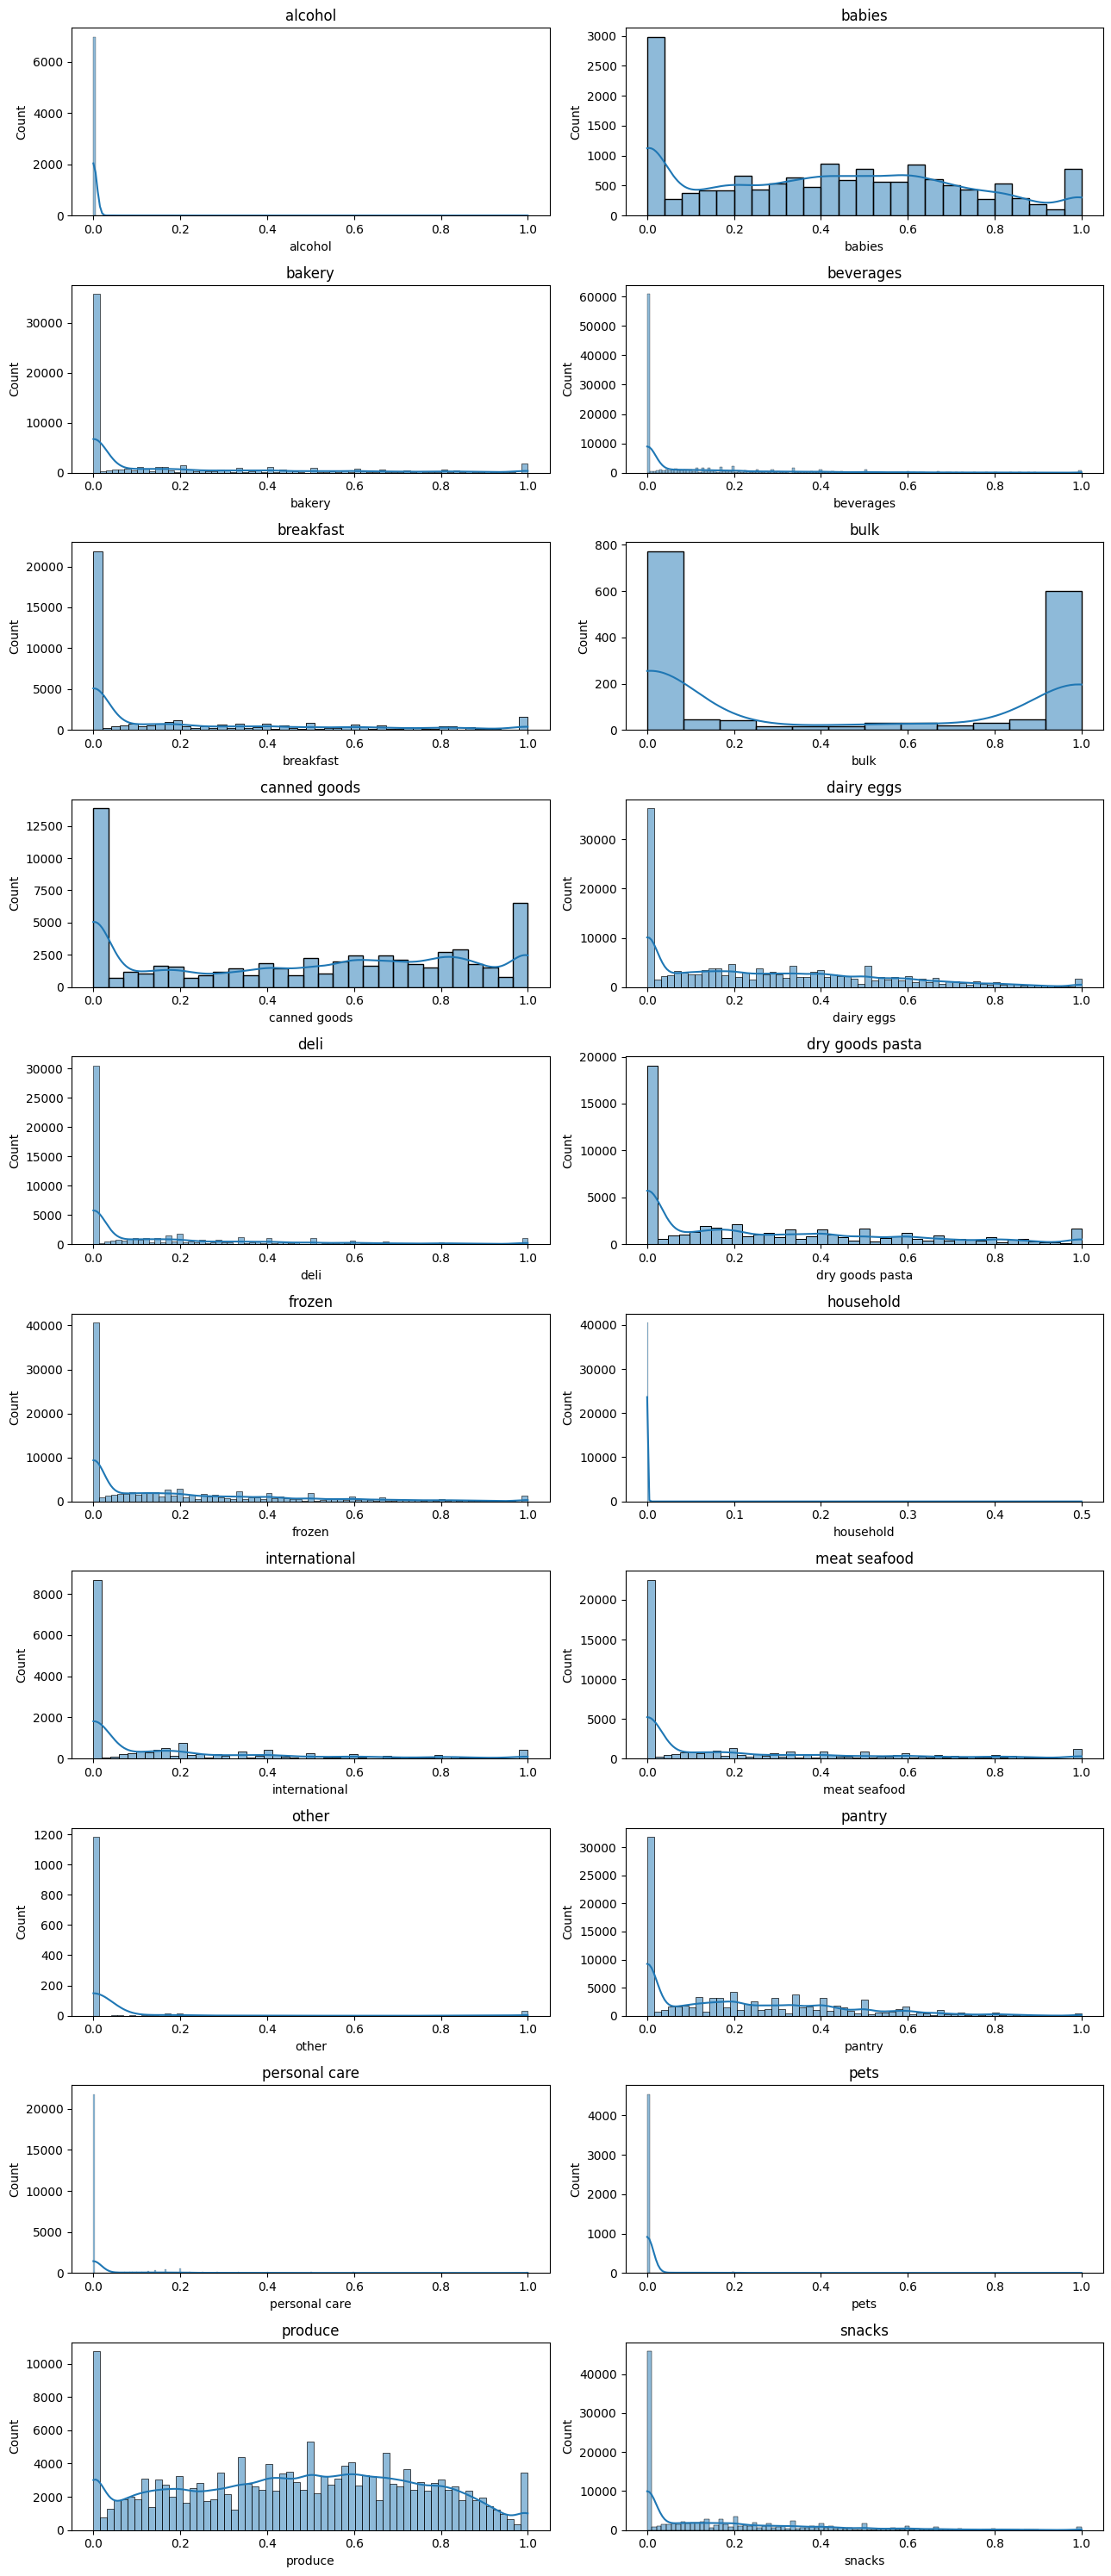

In [35]:
fig, axes = plt.subplots(10, 2, figsize=(13, 30))
department_list = user_level_data.columns.tolist()


for ax, dept in zip(axes.flatten(), department_list):
    mask = counts_per_user[dept] >= 5
    filtered = user_level_data[dept][mask].dropna()
    sns.histplot(data=filtered, ax=ax, kde=True)
    ax.set_title(dept)

plt.tight_layout()

Before proceeding with clustering, we want to narrow down the features (departments) by examining the correlations between each pair of departments. We will restrict to users who have data in all candidate departments, then compute correlations on that fixed subset.

#### Concerns associated with too many departments
There are two main concerns that we want to address by limiting the number of departments:
1. First, customers rarely shop across all 20 departments, causing a sparse space and requiring NaN values for each user in each department to be heavily imputed.
2. Multicollinearity exists when a number of categories all move together. 

#### Criteria for selecting departments
The candidate departments will be selected based on both the spread and coverage. 

Regarding the spread, we ask "does the distribution actually vary across users?". Based on the distributions, we see that in the following departments, almost everyone is at 0.0 (conventional), indicating that they have essentially no discriminating power and should be excluded from the core departments:
- alcohol
- bakery
- beverages
- breakfast
- deli
- household
- other
- pets
- international
- personal care

Next, we ask "do enough users shop here?". From the distributions, we observed that even though there's a clear bimodal pattern in bulk, the y axis tops out around 800, which means very few users shop bulk. If we include it, we would shrink our sample dramatically for a department only a tiny fraction engages with. For the same reason, we exclude babies category.

This leaves us with the following candidate departments:
- canned goods
- dairy eggs
- pantry
- frozen
- produce
- dry goods pasta
- meat seafood
- snacks

### 3. Correlation

In [36]:
cand_depart = [
    "canned goods",
    "dairy eggs",
    "pantry",
    "frozen",
    "dry goods pasta",
    "meat seafood",
    "snacks",
    "produce",
]

department_mask = (counts_per_user[cand_depart] >= 5).all(axis=1)
filtered_user_data = user_level_data[cand_depart][department_mask]
filtered_user_data.head()

department,canned goods,dairy eggs,pantry,frozen,dry goods pasta,meat seafood,snacks,produce
user_id,,,,,,,,
38,0.833,0.277,0.300,0.550,0.143,0.556,0.385,0.833
46,0.500,0.333,0.375,0.000,0.000,0.000,0.000,0.091
54,0.463,0.423,0.181,0.167,0.000,0.143,0.000,0.524
63,0.833,0.576,0.189,0.283,0.865,0.185,0.200,0.872
71,1.000,0.231,0.040,0.000,0.789,0.474,0.045,0.529


<Axes: xlabel='department', ylabel='department'>

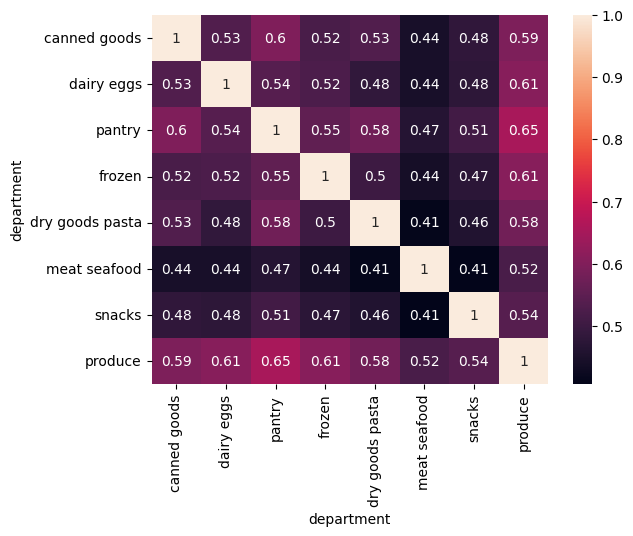

In [37]:
sns.heatmap(filtered_user_data.corr(method="spearman"), annot=True)

From the heatmap, we can see that there is no redundant correlation. The spearman correlations sit between 0.4 and 0.65 and are generally considered to be moderate correlations. This suggests that no pair is so correlated that it's essentially a duplicate feature. Therefore, we keep all 8 departments as clustering features.

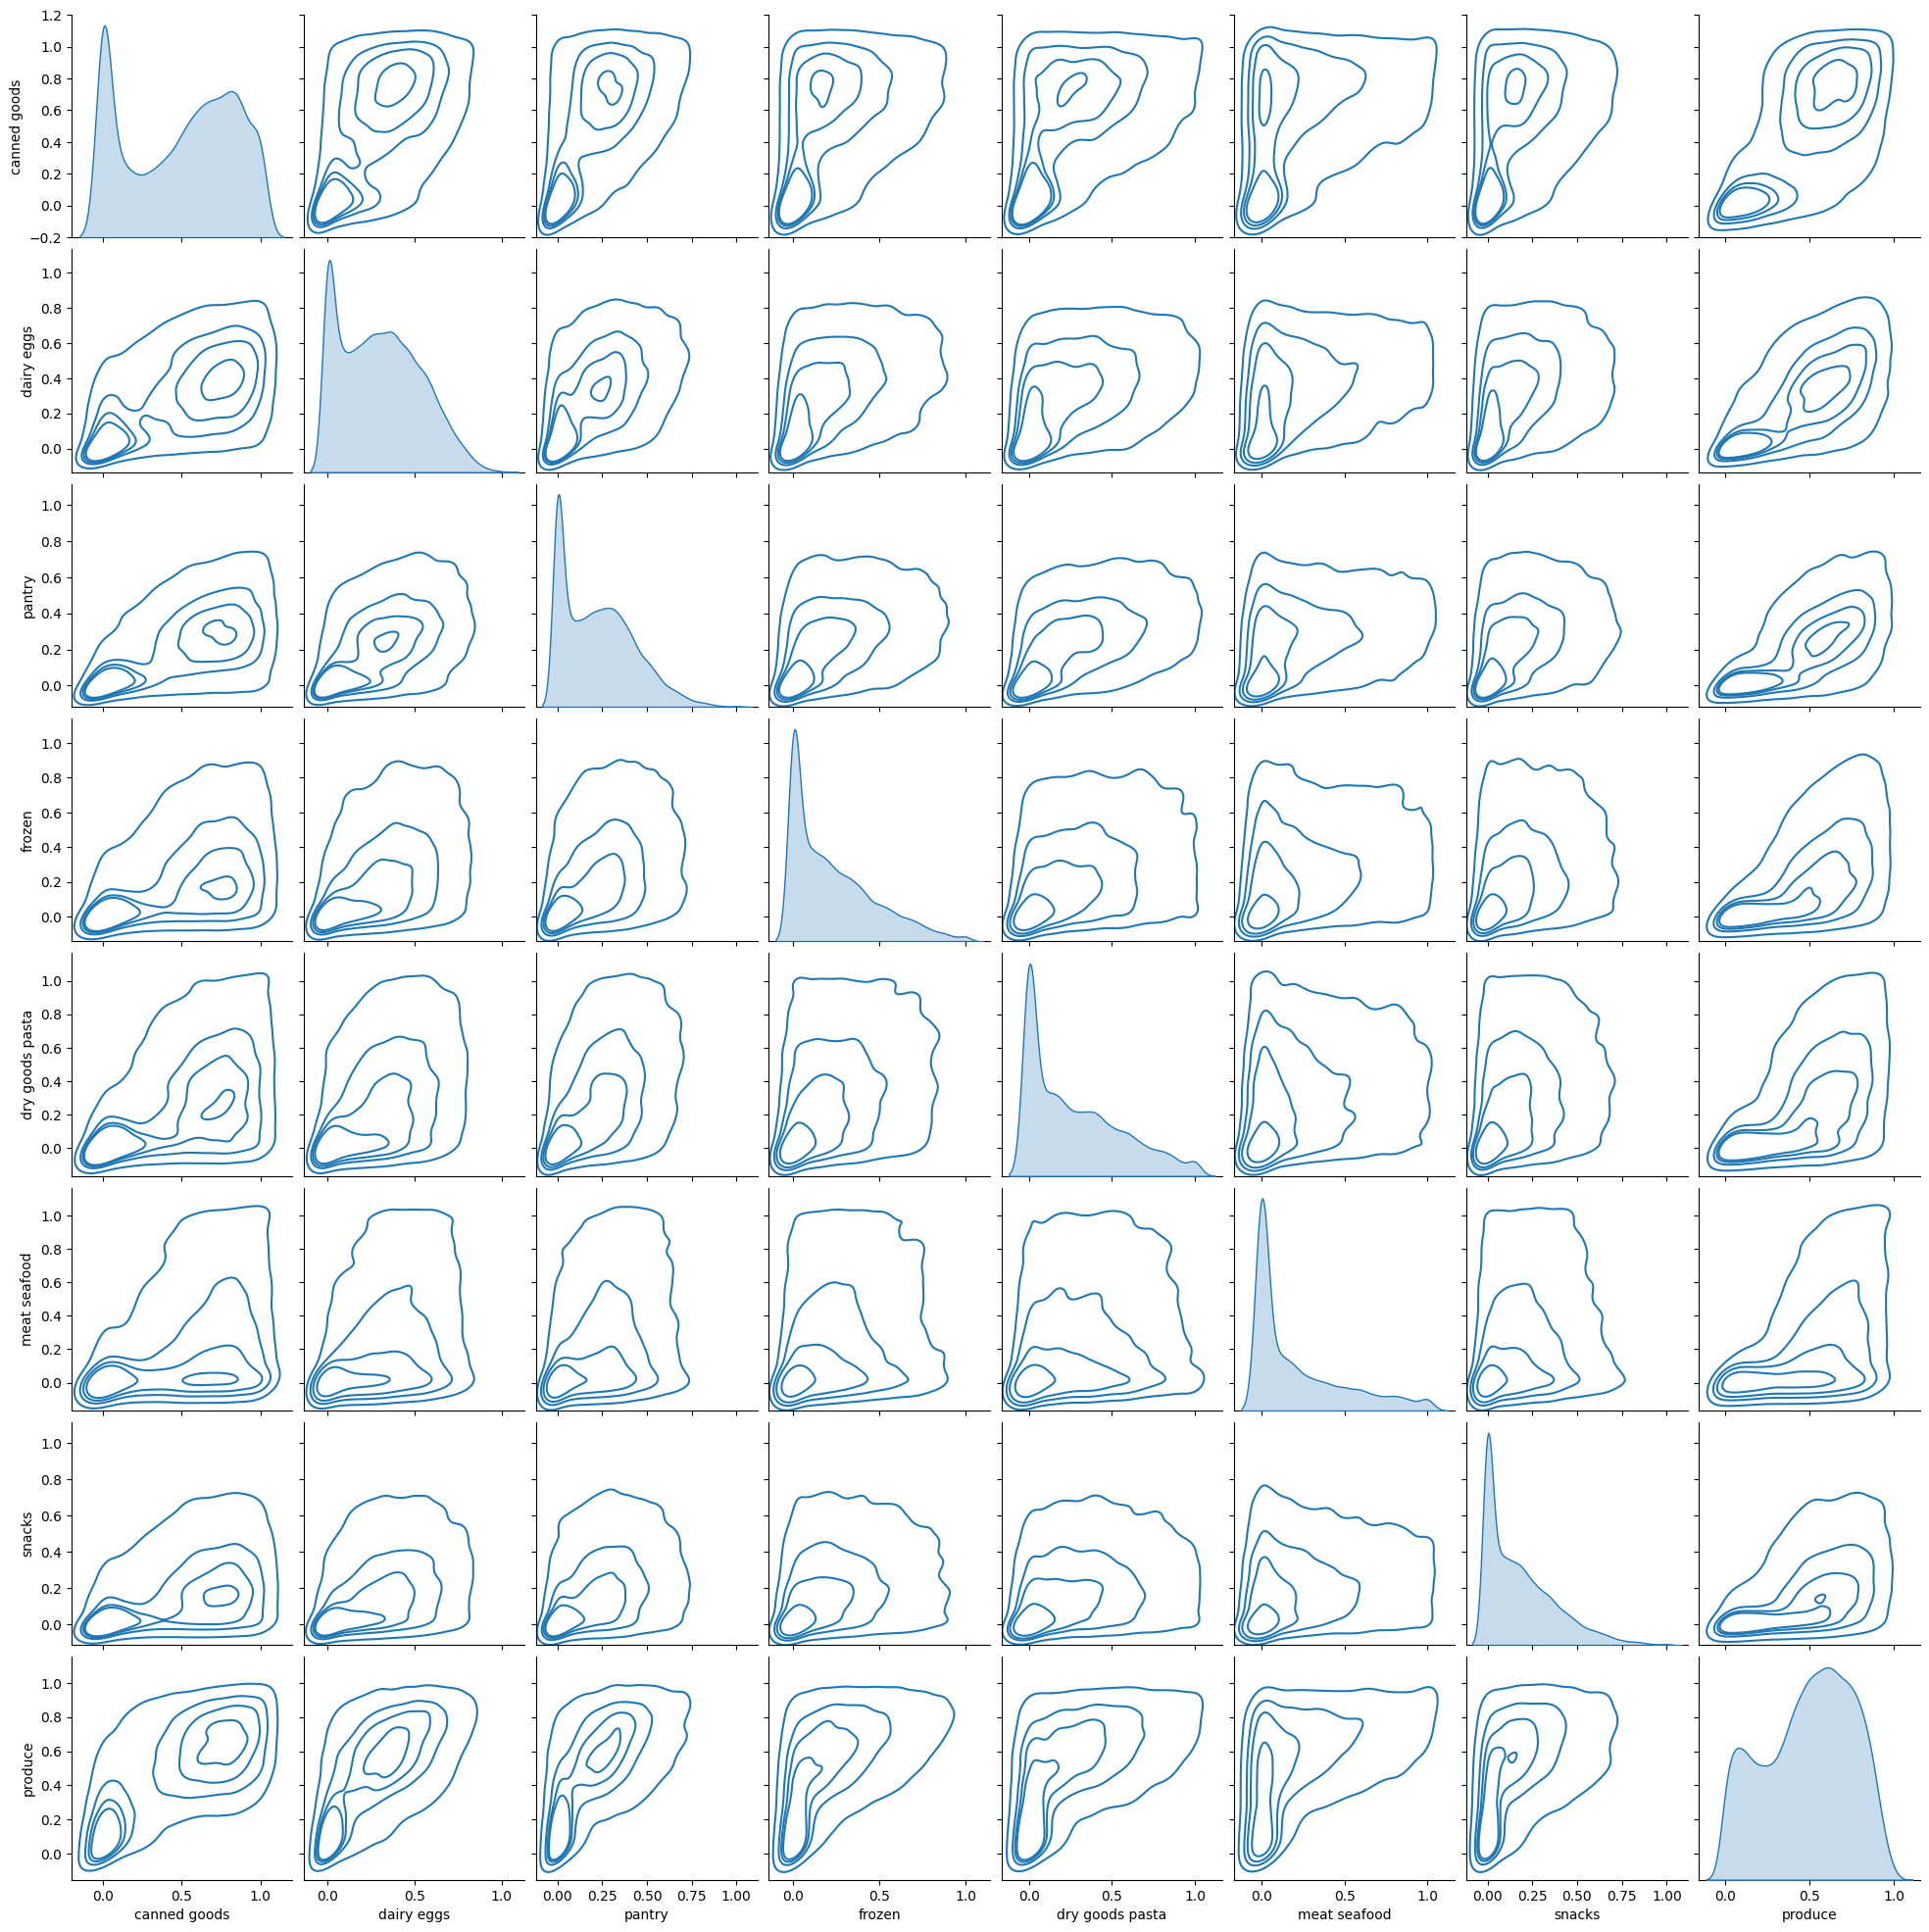

In [38]:
sns.pairplot(filtered_user_data, kind="kde", plot_kws={"levels": 5})

In the KDE plots, each off-diagonal panel shows the joint density of two departments across users. Each ring represents a density level, and the innermost ring is the peak. Multiple separate peaks represent multimodal joint distribution, which suggests users can be clumped into distinct sub-groups. In contrast, the diagonal panels are 1D KDEs.

The observations that we can make based on this KDE plot are the following:
- Roughly half of off-diagonal panels show two peaks. Take canned goods and produce for instance, where we can clearly see a peak near (0, 0.1) meaning low organic in canned goods and produce, and a separate peak near (0.7, 0.7) meaning high organic purchase ratio in both.
- The peak doesn't always sit on a clean diagonal. Take produce vs meat seafood for instance, where the peak centered low in meat seafood and stretched broadly across produce (~0.2 - 0.8). It suggests that users vary widely in how much organic produce they buy but almost everyone buys little organic meat/seafood.
- The marginal diagonals confirm bimodality. Take canned goods diagonal for example. We can see a clear two-humped distribution with one bump at 0 and another around 0.8. In comparison, frozen, dry goods pasta, meat seafood, and snacks are strongly right-skewed with the main mass at 0.

Sections 4 - 6 address strategy (a) from the introduction: personalized sponsored product ads. In Section 4, GMM clustering is performed on customers with at least 5 orders (to avoid sparse organic-share patterns from low-history customers), using organic-share features from 8 selected departments. The goal is to identify behavioral segments distinct enough to support differentiated ad recommendations.

Section 5 quantitatively validates the chosen number of clusters via bootstrap stability analysis. Section 6 profiles each cluster's behavior to derive concrete ad recommendations.

### 4. GMM Clustering

In [39]:
from sklearn.mixture import GaussianMixture

In [86]:
k_list = [i for i in range(1, 9)]
GMM_res = {"k": k_list, "BIC": [], "AIC": [], "log_likelihood": [], "models": []}

for k in k_list:
    gm = GaussianMixture(
        n_components=k, covariance_type="full", n_init=10, random_state=42
    ).fit(filtered_user_data)
    GMM_res["BIC"].append(gm.bic(filtered_user_data))
    GMM_res["AIC"].append(gm.aic(filtered_user_data))
    GMM_res["log_likelihood"].append(
        gm.score(filtered_user_data) * len(filtered_user_data)
    )
    GMM_res["models"].append(gm)

In [41]:
pd.DataFrame(
    {
        "k": GMM_res["k"],
        "BIC": GMM_res["BIC"],
        "AIC": GMM_res["AIC"],
        "log_likelihood": GMM_res["log_likelihood"],
    }
)

,k,BIC,AIC,log_likelihood
0,1,-43756.355,-44095.081,22091.540
1,2,-116728.140,-117413.289,58795.644
2,3,-125754.309,-126785.882,63526.941
3,4,-178541.555,-179919.552,90138.776
4,5,-181341.203,-183065.624,91756.812
5,6,-182689.407,-184760.251,92649.126
6,7,-192861.396,-195278.664,97953.332
7,8,-183918.562,-186682.254,93700.127


All three metrics (BIC, AIC, log-likelihood) reach a minimum at k=7, which far exceeds our hypothesized cluster size (3). To evaluate the reasonableness of k=7 as cluster size, we perform further examination when k = 3, 4, and 7 below.

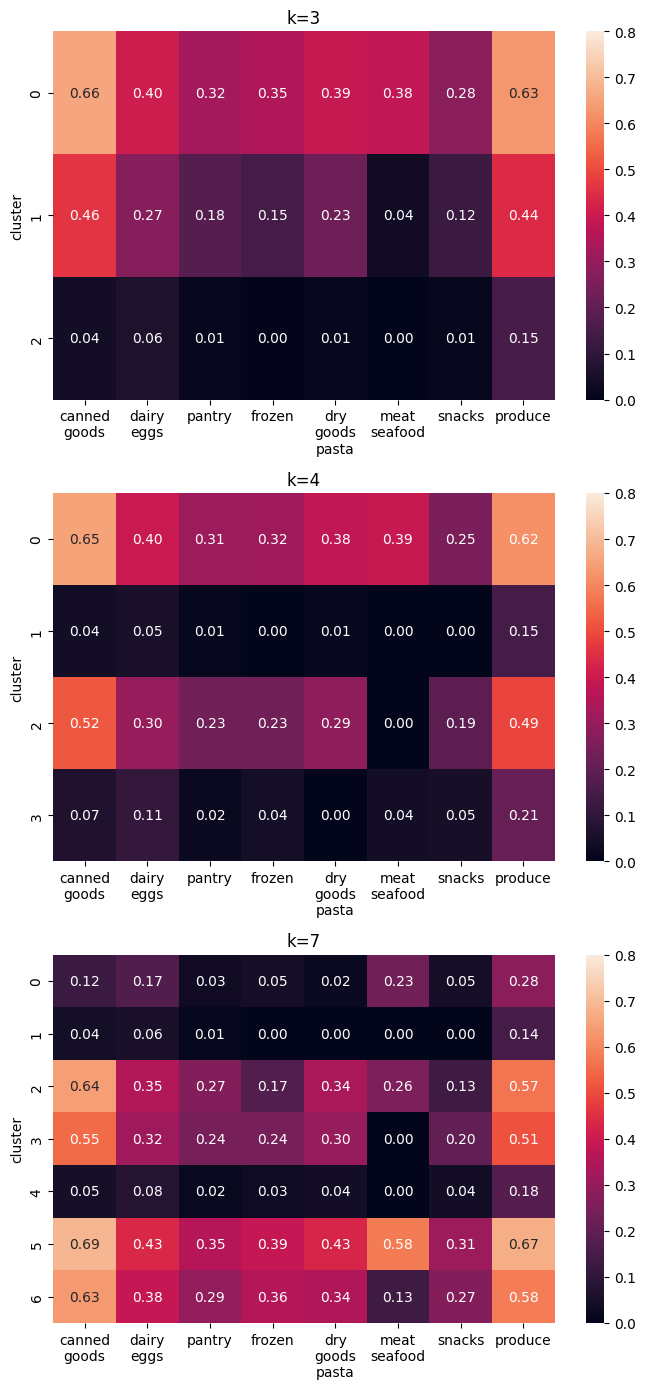

In [42]:
# Wrap column names to reduce crowding
columns = filtered_user_data.columns
wrapped_cols = []
for col in columns:
    wrapped_cols.append("\n".join(col.split(" ")))

fig, axes = plt.subplots(3, 1, figsize=(7, 14))

# Get the GMM models for k clusters where k = 3, 4, 7
k3_model = GMM_res["models"][k_list.index(3)]
k4_model = GMM_res["models"][k_list.index(4)]
k7_model = GMM_res["models"][k_list.index(7)]

for ax, model, title in [
    (axes[0], k3_model, "k=3"),
    (axes[1], k4_model, "k=4"),
    (axes[2], k7_model, "k=7"),
]:
    means = pd.DataFrame(model.means_, columns=wrapped_cols)
    sns.heatmap(means, annot=True, fmt=".2f", ax=ax, vmin=0, vmax=0.8)
    ax.set_title(title)
    ax.set_ylabel("cluster")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()

Although GMM prefers k=7, we don't think k=7 is a reasonable cluster size for two reasons:
1. Cluster duplication. Inspection of the k=7 cluster means revealed near-identical pairs (cluster 1 and 4 both represent near-zero-organic shoppers; cluster 3 and 6 both represent moderate-organic shoppers who avoid meat/seafood). Distinct user types should have meaningfully different mean profiles.
2. Gaussian misfit artifact. GMM assumes each cluster follows a multivariate Gaussian distribution, but our features are bounded organic shares in [0, 1] with a heavy point mass at exact 0 for several departments. When the underlying data is non-Gaussian, GMM compensates by stacking multiple Gaussian components to approximate the irregular shape of a single underlying group, rather than identifying additional user types. This inflates the BIC-optimal k beyond the true number of behavioral segments.

We noted similar issue with k=4 where cluster 1 and 3 representing near-zero-organic shoppers. 

In contrast, at k=3, every cluster has a clear, distinct interpretation that aligns with the hypothesis. At higher k, interpretability degrades while the additional clusters do not surface meaningful new user behavior.

Next, we perform cluster stability test with 50 runs using bootstrap (without replacement) and ARI (Adjusted Rand Index) to quantitatively determine the best k value.

### 5. Cluster Stability Test (Subsample and ARI)

In [87]:
from collections import defaultdict
from itertools import combinations
from sklearn.metrics import adjusted_rand_score

N_RUNS = 50
sample_size = int(
    filtered_user_data.shape[0] * 0.8
)  # Subsample 80% of full dataset used for GMM clustering
gmm_res_dict = defaultdict(dict)

for run in range(N_RUNS):
    subsample_df = filtered_user_data.sample(n=sample_size, random_state=run)
    for k in k_list:
        gm = GaussianMixture(
            n_components=k, covariance_type="full", n_init=10, random_state=run
        ).fit(subsample_df)
        cluster_assignments = pd.Series(
            gm.predict(subsample_df), index=subsample_df.index, name=f"cluster_{run}"
        )
        gmm_res_dict[k][run] = cluster_assignments

res = []

for k in k_list:
    for i, j in combinations(range(N_RUNS), 2):
        series_i = gmm_res_dict[k][i]
        series_j = gmm_res_dict[k][j]
        overlap = pd.concat([series_i, series_j], join="inner", axis=1)
        ari = adjusted_rand_score(overlap.iloc[:, 0], overlap.iloc[:, 1])
        res.append({"k": k, "run_i": i, "run_j": j, "ari": ari})

res_df = pd.DataFrame(res)

/Users/jingma/Desktop/Instacart Data Analytics/.venv/lib/python3.13/site-packages/sklearn/mixture/_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


In [88]:
res_df.groupby("k")["ari"].agg(["mean", "std", "median"])

,mean,std,median
k,,,
1,1.000,0.000,1.000
2,0.986,0.007,0.987
3,0.748,0.226,0.898
4,0.980,0.028,0.994
5,0.880,0.096,0.920
6,0.772,0.094,0.773
7,0.735,0.090,0.723
8,0.646,0.089,0.628


In [45]:
def fit_at_seed(data, k, seed):
    subsample = data.sample(n=sample_size, random_state=seed)
    gm = GaussianMixture(
        n_components=k, covariance_type="full", n_init=10, random_state=seed
    ).fit(subsample)
    return gm, subsample

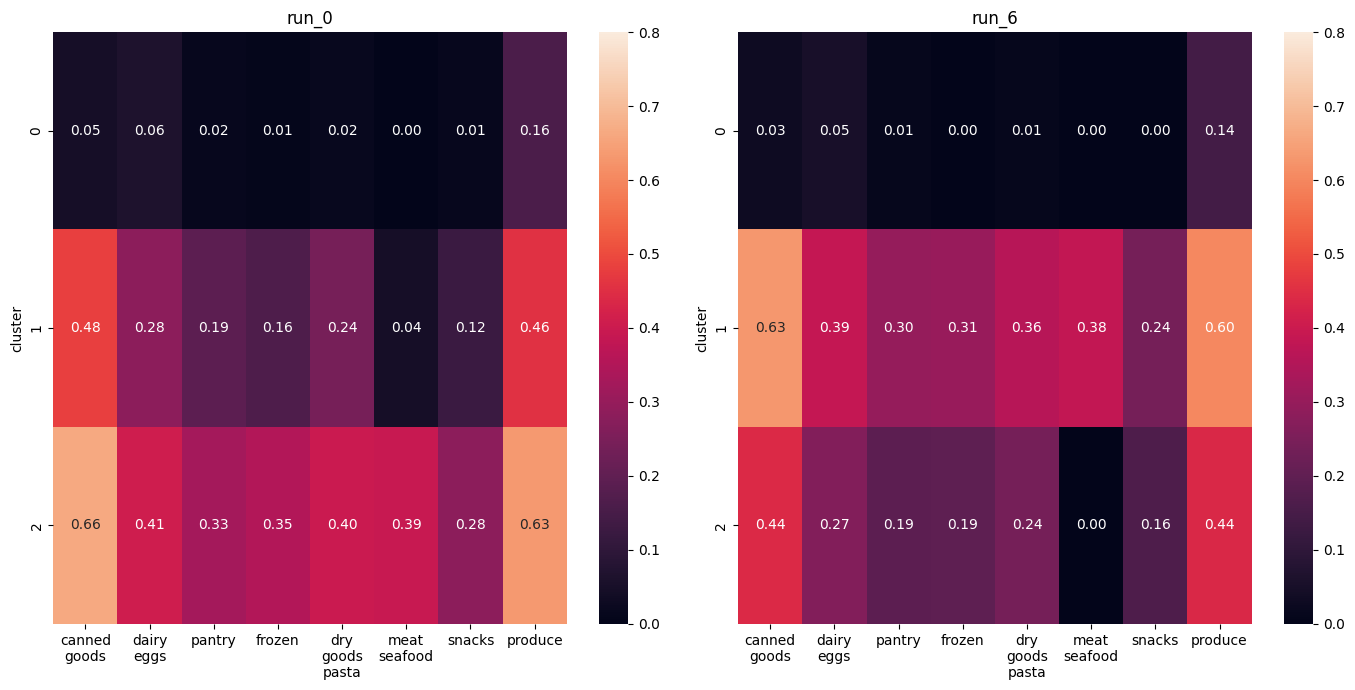

In [46]:
# When k = 3, run_i = 0, run_j = 6, ari = 0.442
gm_run_0_k_3, subsample_run_0_k_3 = fit_at_seed(filtered_user_data, 3, 0)
gm_run_6_k_3, subsample_run_6_k_3 = fit_at_seed(filtered_user_data, 3, 6)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, model, title in [
    (axes[0], gm_run_0_k_3, "run_0"),
    (axes[1], gm_run_6_k_3, "run_6"),
]:
    means = pd.DataFrame(model.means_, columns=wrapped_cols)
    sns.heatmap(means, annot=True, fmt=".2f", ax=ax, vmin=0, vmax=0.8)
    ax.set_title(title)
    ax.set_ylabel("cluster")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()

<Axes: ylabel='Density'>

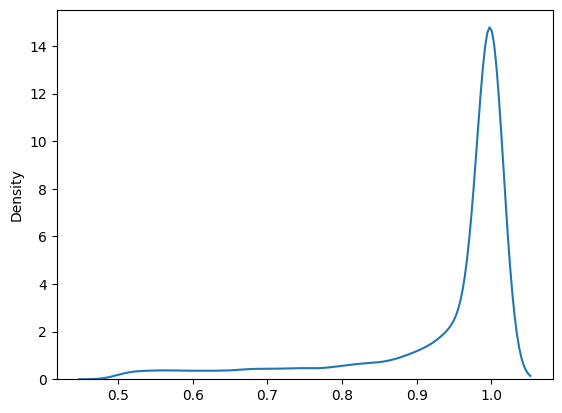

In [47]:
probs = gm_run_0_k_3.predict_proba(subsample_run_0_k_3)
df_probs = pd.DataFrame(probs, columns=[f"cluster_{i}" for i in range(3)])
df_max_probs_k_3 = df_probs.max(axis=1)
sns.kdeplot(df_max_probs_k_3)

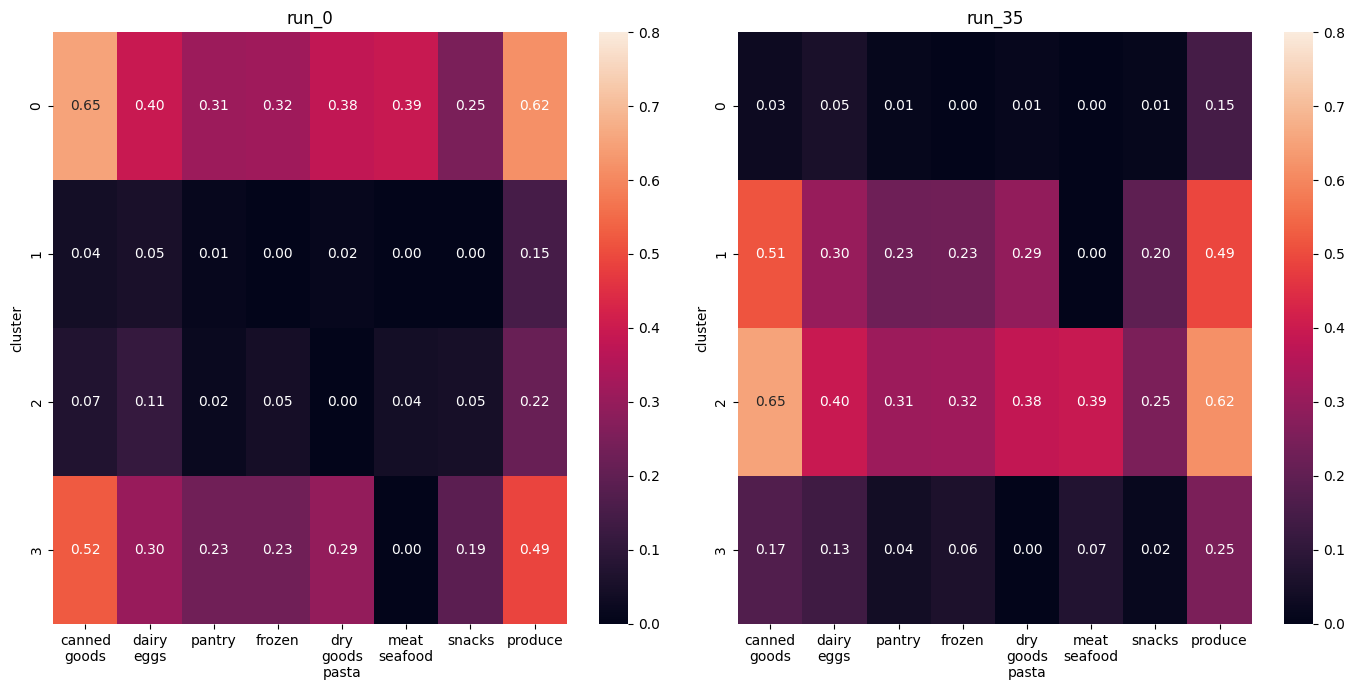

In [48]:
# When k = 4, run_i = 0, run_j = 35, ari = 0.920
gm_run_0_k_4, subsample_run_0_k_4 = fit_at_seed(filtered_user_data, 4, 0)
gm_run_35_k_4, subsample_run_35_k_4 = fit_at_seed(filtered_user_data, 4, 35)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, model, title in [
    (axes[0], gm_run_0_k_4, "run_0"),
    (axes[1], gm_run_35_k_4, "run_35"),
]:
    means = pd.DataFrame(model.means_, columns=wrapped_cols)
    sns.heatmap(means, annot=True, fmt=".2f", ax=ax, vmin=0, vmax=0.8)
    ax.set_title(title)
    ax.set_ylabel("cluster")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()

<Axes: ylabel='Density'>

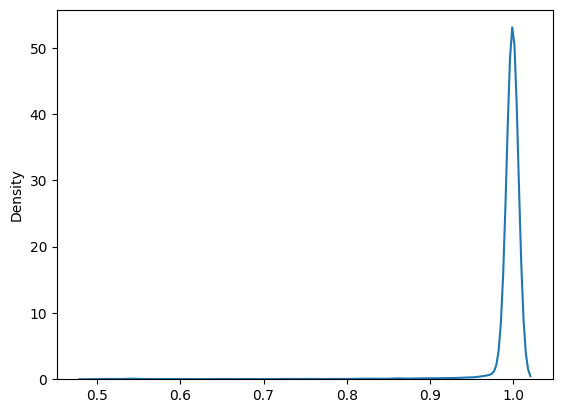

In [49]:
probs = gm_run_35_k_4.predict_proba(subsample_run_35_k_4)
df_probs = pd.DataFrame(probs, columns=[f"cluster_{i}" for i in range(4)])
df_max_probs_k_4 = df_probs.max(axis=1)
sns.kdeplot(df_max_probs_k_4)

In [50]:
new_cluster_assignments = pd.Series(
    gm_run_35_k_4.predict(subsample_run_35_k_4),
    index=subsample_run_35_k_4.index,
    name="cluster",
)
new_cluster_assignments.value_counts().sort_index()

cluster
0    1959
1    3127
2    6978
3     968
Name: count, dtype: int64

In [51]:
new_cluster_assignments = pd.Series(
    gm_run_6_k_3.predict(subsample_run_6_k_3),
    index=subsample_run_6_k_3.index,
    name="cluster",
)
new_cluster_assignments.value_counts().sort_index()

cluster
0    1802
1    7414
2    3816
Name: count, dtype: int64

Based on the bootstrap stability analysis, k=7 was eliminated on quantitative grounds: mean ARI of 0.735 and median of 0.723 were both lower than k=4, indicating less stable assignments. Further, combined with the original cluster-means heatmap that showed near-duplicate cluster pairs (cluster 1 and 4, clusters 3 and 6), both pointing to over-fitting.

The remaining choice, k=3 vs k=4, was less obvious. Bootstrap stability favored k=4 (mean ARI 0.98 vs 0.75). Investigating the source of k=3's instability, we found that cluster centers were consistent across runs but boundary assignment varied, which indicates that typology was stable but partition was not. Investigating k=4's additional cluster, we found it represented a split of the low-organic group into 'near-zero' and 'low' sub-segments differing in level rather than in qualitative behavior. For the downstream ad personalization use case, this split doesn't change recommendations as both sub-segments shop predominantly conventional groceries. Therefore, I retained k = 3 to avoid splitting a behaviorally homogeneous segment.

### 6. Cluster Profiling

In [52]:
cluster_assignments = pd.Series(
    k3_model.predict(filtered_user_data), index=filtered_user_data.index, name="cluster"
)
cluster_assignments.head()

user_id
38    0
46    1
54    1
63    0
71    0
Name: cluster, dtype: int64

In [53]:
# Count users per cluster
cluster_assignments.value_counts().sort_index()

cluster
0    8850
1    4490
2    2950
Name: count, dtype: int64

Within our filtered cohort of engaged users (>= 5 orders across the 8 departments), we observed that ~54% of users are organic-leaning, ~28% are selective, and ~18% are conventional-leaning. The cluster sizes likely overstate the organic-leaning share in the general population for two reasons:
1. Instacart users skew more affluent than typical grocery shoppers due to delivery fees, service fees, and tips, biasing toward price-tolerant organic buyers.
2. Our filter to users with >= 5 purchases in 8 departments selects for power users. These segment proportions describe behavior within Instacart's engaged user base, not the broader grocery-shopping population.

In [54]:
merged_w_cluster = clean_df.merge(cluster_assignments, on="user_id", how="inner")
merged_w_cluster.head()

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,organic,cluster
0,5,13176,1,1,Bag of Organic Bananas,24,4,fresh fruits,produce,156122,42,6,16,9.000,1,2
1,5,15005,2,1,"Just Crisp, Parmesan",89,13,salad dressing toppings,pantry,156122,42,6,16,9.000,0,2
2,5,47329,3,1,Fresh Fruit Salad,1,20,prepared soups salads,deli,156122,42,6,16,9.000,0,2
3,5,27966,4,1,Organic Raspberries,123,4,packaged vegetables fruits,produce,156122,42,6,16,9.000,1,2
4,5,23909,5,1,2% Reduced Fat Milk,84,16,milk,dairy eggs,156122,42,6,16,9.000,0,2


In [55]:
user_aisle_binary = merged_w_cluster.groupby(["user_id", "aisle"]).size().unstack() > 0
user_aisle_binary["cluster"] = cluster_assignments
user_aisle_binary.head()

aisle,air fresheners candles,asian foods,baby accessories,baby bath body care,baby food formula,bakery desserts,baking ingredients,baking supplies decor,beauty,beers coolers,...,tea,tofu meat alternatives,tortillas flat bread,trail mix snack mix,trash bags liners,vitamins supplements,water seltzer sparkling water,white wines,yogurt,cluster
user_id,,,,,,,,,,,,,,,,,,,,,
38,False,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,True,False,False,0
46,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,1
54,True,True,False,False,False,False,True,False,False,False,...,True,True,True,False,False,True,True,False,True,1
63,False,True,False,False,False,False,True,True,False,False,...,False,True,False,False,False,True,False,False,True,0
71,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,0


In [56]:
cluster_penetration = user_aisle_binary.groupby("cluster").mean()
overall_penetration = user_aisle_binary.drop(columns="cluster").mean()
# Compute lift = rate_of_behavior_in_cluster / rate_of_behavior_in_population
lift = cluster_penetration / overall_penetration
lift

aisle,air fresheners candles,asian foods,baby accessories,baby bath body care,baby food formula,bakery desserts,baking ingredients,baking supplies decor,beauty,beers coolers,...,spreads,tea,tofu meat alternatives,tortillas flat bread,trail mix snack mix,trash bags liners,vitamins supplements,water seltzer sparkling water,white wines,yogurt
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.640,1.019,1.322,1.108,1.232,1.038,1.009,0.832,0.789,0.221,...,1.033,1.060,1.208,0.958,1.094,0.690,1.274,1.021,0.245,1.032
1,0.938,1.028,0.832,0.874,0.865,0.940,1.001,0.954,1.122,1.154,...,0.984,0.979,1.043,1.013,0.840,1.024,0.824,1.017,1.226,1.003
2,2.175,0.902,0.290,0.868,0.510,0.977,0.973,1.573,1.449,3.104,...,0.927,0.850,0.310,1.106,0.961,1.893,0.447,0.912,2.920,0.901


In [57]:
cluster_penetration.head()

aisle,air fresheners candles,asian foods,baby accessories,baby bath body care,baby food formula,bakery desserts,baking ingredients,baking supplies decor,beauty,beers coolers,...,spreads,tea,tofu meat alternatives,tortillas flat bread,trail mix snack mix,trash bags liners,vitamins supplements,water seltzer sparkling water,white wines,yogurt
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.056,0.634,0.068,0.086,0.413,0.140,0.842,0.164,0.038,0.009,...,0.811,0.515,0.308,0.626,0.137,0.120,0.282,0.705,0.010,0.950
1,0.082,0.639,0.043,0.068,0.290,0.127,0.835,0.188,0.054,0.050,...,0.773,0.476,0.266,0.662,0.105,0.178,0.182,0.702,0.050,0.923
2,0.189,0.561,0.015,0.067,0.171,0.132,0.812,0.309,0.070,0.134,...,0.728,0.413,0.079,0.723,0.120,0.329,0.099,0.629,0.118,0.830


In [58]:
# Convert lift and cluster_penetration to long form
lift_long = lift.reset_index().melt(
    id_vars="cluster", var_name="aisle", value_name="lift"
)

cluster_penetration_long = cluster_penetration.reset_index().melt(
    id_vars="cluster", var_name="aisle", value_name="penetration"
)

merged_lift_w_penetration = lift_long.merge(
    cluster_penetration_long, on=["cluster", "aisle"], how="left"
)
print("Data validation check\n", merged_lift_w_penetration.isnull().sum())
print("\n")

print("-------Merged lift with penetration-------")
print(merged_lift_w_penetration.head())

Data validation check
 cluster        0
aisle          0
lift           0
penetration    0
dtype: int64


-------Merged lift with penetration-------
   cluster                   aisle  lift  penetration
0        0  air fresheners candles 0.640        0.056
1        1  air fresheners candles 0.938        0.082
2        2  air fresheners candles 2.175        0.189
3        0             asian foods 1.019        0.634
4        1             asian foods 1.028        0.639


In [59]:
top_10_lift = (
    merged_lift_w_penetration[merged_lift_w_penetration["penetration"] >= 0.3]
    .sort_values(["cluster", "lift"], ascending=[True, False])
    .groupby("cluster")
    .head(10)
)
top_10_lift

,cluster,aisle,lift,penetration
345,0,soap,1.311,0.396
12,0,baby food formula,1.232,0.413
375,0,tofu meat alternatives,1.208,0.308
192,0,fruit vegetable snacks,1.147,0.554
198,0,granola,1.144,0.352
354,0,soy lactosefree,1.124,0.813
246,0,meat counter,1.106,0.449
312,0,prepared meals,1.103,0.332
309,0,poultry counter,1.100,0.621
153,0,fresh herbs,1.094,0.826


In [60]:
top_10_penetration = (
    merged_lift_w_penetration.sort_values(
        ["cluster", "penetration"], ascending=[True, False]
    )
    .groupby("cluster")
    .head(10)
)
top_10_penetration

,cluster,aisle,lift,penetration
150,0,fresh fruits,1.006,0.999
159,0,fresh vegetables,1.006,0.999
291,0,packaged vegetables fruits,1.007,0.997
276,0,packaged cheese,1.001,0.975
396,0,yogurt,1.032,0.950
186,0,frozen produce,1.027,0.913
351,0,soup broth bouillon,0.999,0.885
120,0,dry pasta,1.002,0.884
75,0,chips pretzels,0.978,0.872
60,0,canned jarred vegetables,1.012,0.865


In [61]:
top_10_lift_and_penetration = pd.concat([top_10_lift, top_10_penetration])
top_10_lift_and_penetration.drop_duplicates(inplace=True)
top_10_lift_and_penetration.shape[0]

60

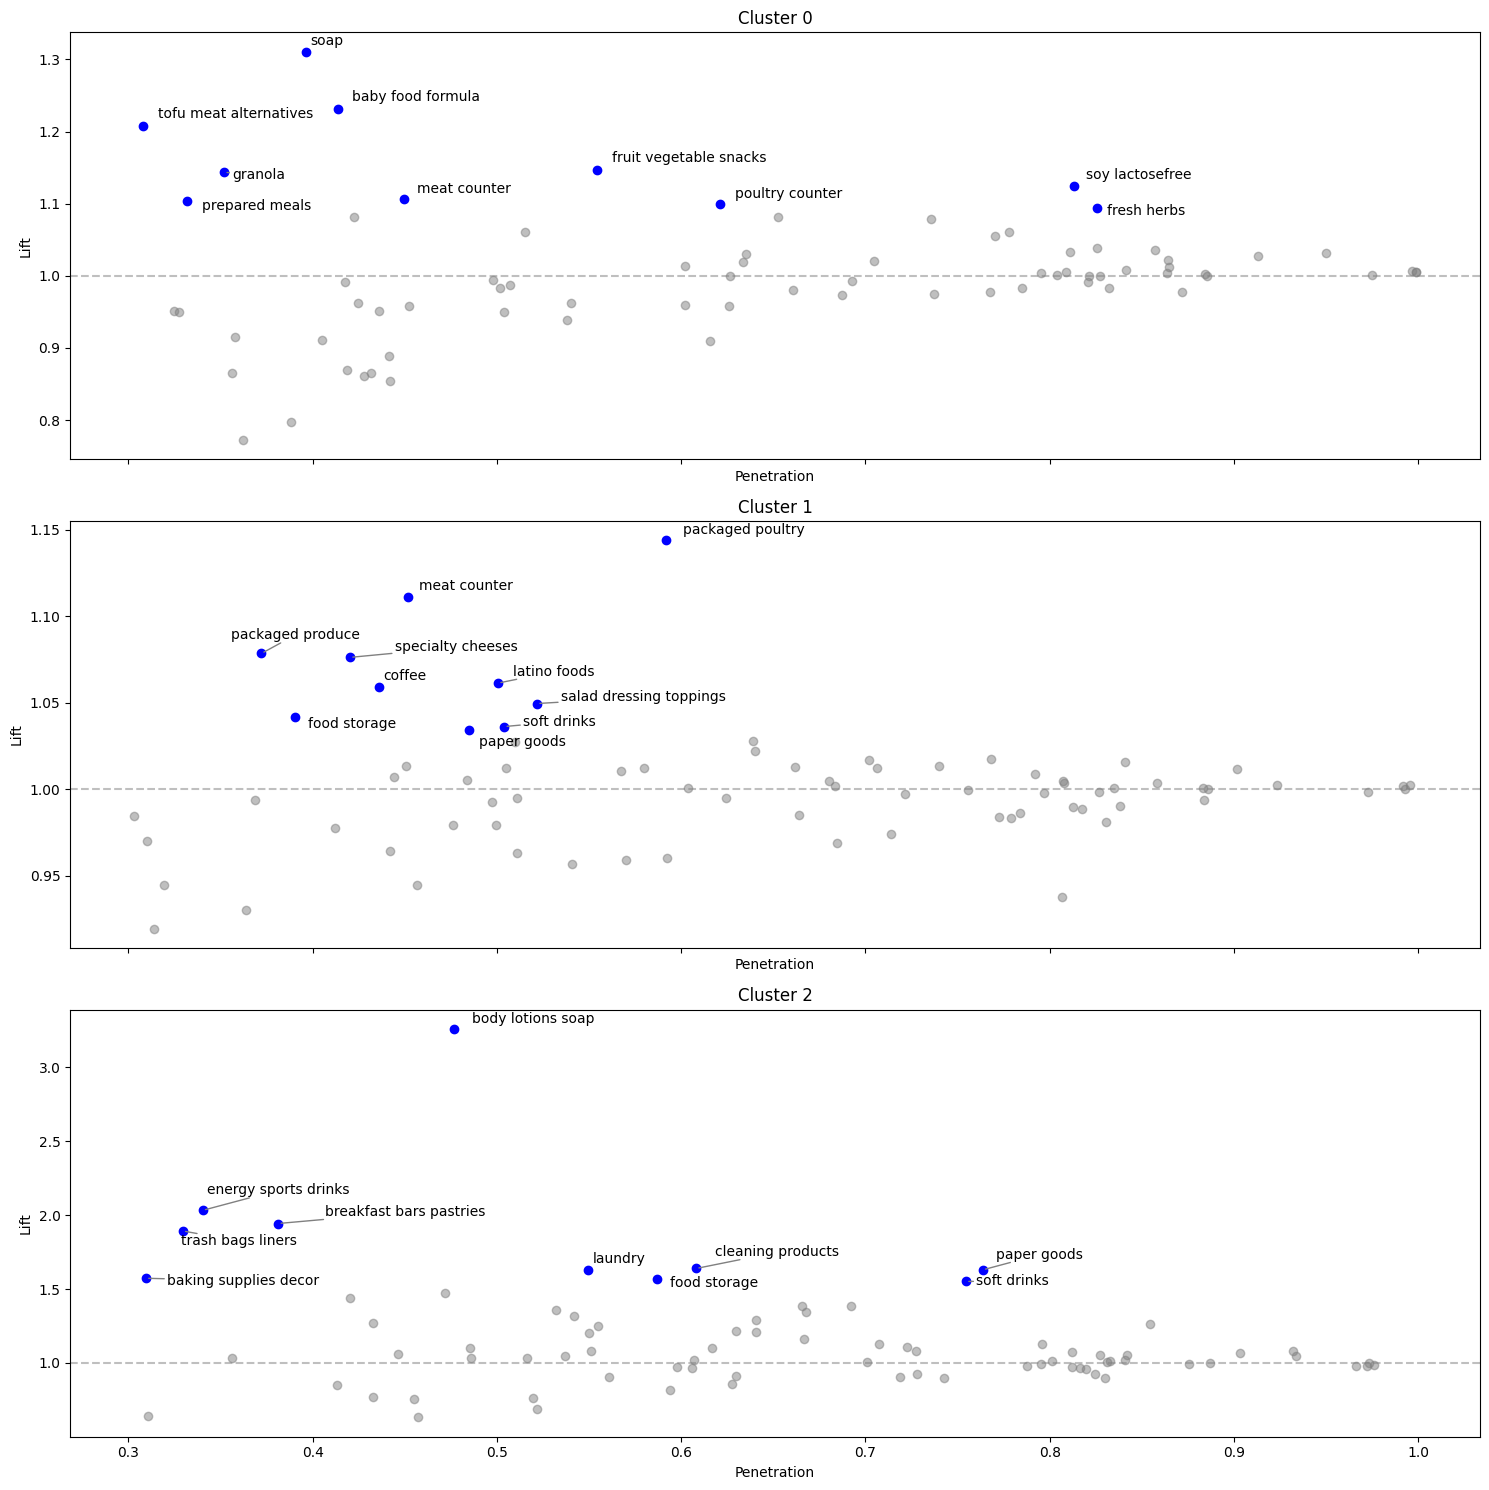

In [62]:
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(15, 15))
for ax, cluster_id in zip(axes, [0, 1, 2]):
    cluster_data = merged_lift_w_penetration[
        (merged_lift_w_penetration["cluster"] == cluster_id)
        & (merged_lift_w_penetration["penetration"] >= 0.3)
    ]

    # Identify top 10 lift aisles for this cluster
    top10 = cluster_data.nlargest(10, "lift")
    rest = cluster_data.drop(top10.index)

    ax.scatter(rest["penetration"], rest["lift"], color="grey", alpha=0.5)
    ax.scatter(top10["penetration"], top10["lift"], color="blue")

    # Labels for top 10
    texts = [
        ax.text(row["penetration"], row["lift"], row["aisle"])
        for _, row in top10.iterrows()
    ]
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="grey"))

    ax.set_title(f"Cluster {cluster_id}")
    ax.axhline(1, linestyle="--", color="gray", alpha=0.5)

    ax.set_xlabel("Penetration")
    ax.set_ylabel("Lift")

plt.tight_layout()

In the scatter plots above, we highlighted top 10 aisles by lift for 30% penetration or higher. Put in plain language, the highlighted data points represent the aisles where each cluster over-indexes the most among the popular aisles (at least 3 in 10 grocers from all clusters shop in these aisles). It validates that the three clusters that we have identified indeed exhibit differing marginal preferences beyond core staples (i.e., fresh fruits and vegetables). However, this is not to overlook the fact that all clusters spend most heavily on fresh groceries and pantry staples.

One issue with the plot is that due to different scaling of y axis, there appears to be notable variations in each cluster, but once plotted on the same scale as shown below, we observed that cluster 1 has lift $\approx$ 1.0 across nearly all high-penetration aisles. Cluster 0 has narrower spread and cluster 2 has a wide spread. This finding suggests that for cluster 0, category preferences provide a moderate secondary signal that complements the primary organic-targeting lever; for cluster 1, the category signal is too weak to act on, leaving the organic/conventional choice as the main lever; for cluster 2, the category signal provides a strong supplementary signal for driving ads decisions when there's an ad slot beyond the core grocery basket, where category alignment can lift the chance of the ad turning into a basket addition.

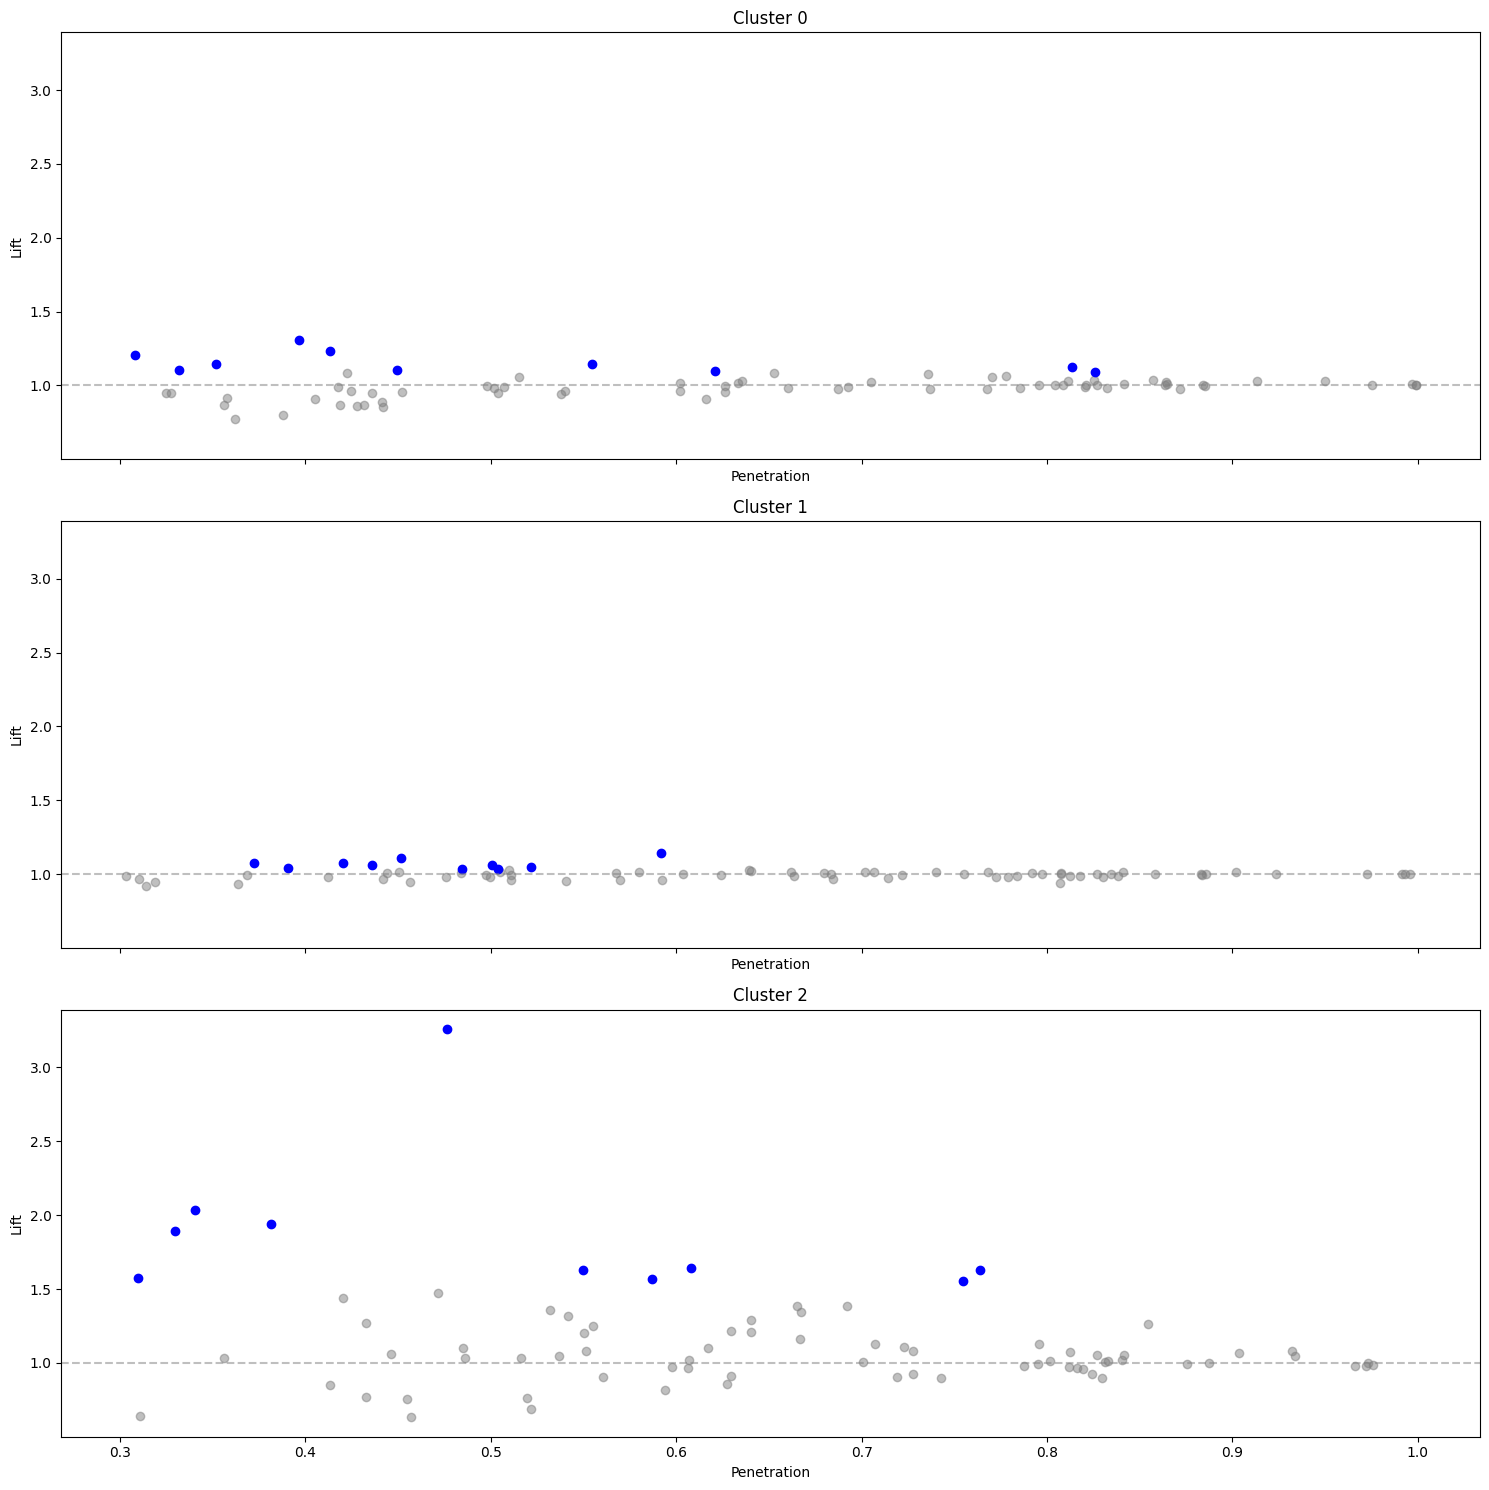

In [63]:
fig, axes = plt.subplots(3, 1, sharex=True, sharey=True, figsize=(15, 15))
for ax, cluster_id in zip(axes, [0, 1, 2]):
    cluster_data = merged_lift_w_penetration[
        (merged_lift_w_penetration["cluster"] == cluster_id)
        & (merged_lift_w_penetration["penetration"] >= 0.3)
    ]

    # Identify top 10 lift aisles for this cluster
    top10 = cluster_data.nlargest(10, "lift")
    rest = cluster_data.drop(top10.index)

    ax.scatter(rest["penetration"], rest["lift"], color="grey", alpha=0.5)
    ax.scatter(top10["penetration"], top10["lift"], color="blue")

    ax.set_title(f"Cluster {cluster_id}")
    ax.axhline(1, linestyle="--", color="gray", alpha=0.5)

    ax.set_xlabel("Penetration")
    ax.set_ylabel("Lift")

plt.tight_layout()

In [64]:
order_count_per_dow = (
    merged_w_cluster.groupby(["cluster", "order_dow"])["order_id"]
    .nunique()
    .reset_index()
    .rename(columns={"order_id": "order_count"})
)
order_count_per_dow["cluster_total"] = order_count_per_dow.groupby("cluster")[
    "order_count"
].transform("sum")
order_count_per_dow["within_cluster_share"] = (
    order_count_per_dow["order_count"] / order_count_per_dow["cluster_total"]
)

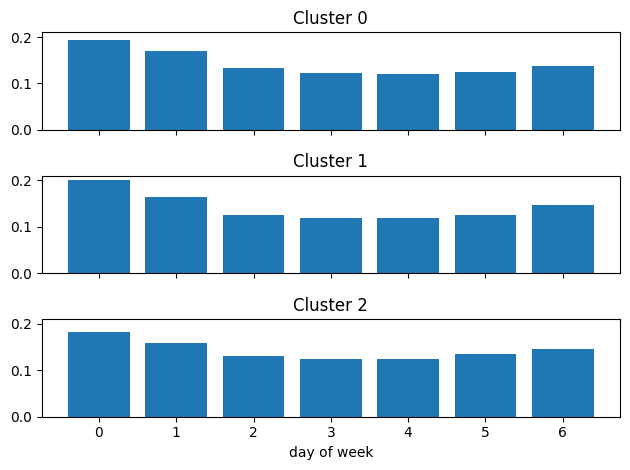

In [ ]:
clusters = [0, 1, 2]

fig, axes = plt.subplots(3, 1, sharey=True, sharex=True)

for ax, cluster in zip(axes.flatten(), clusters):
    filtered_data = order_count_per_dow.loc[order_count_per_dow["cluster"] == cluster]
    ax.bar(filtered_data["order_dow"], filtered_data["within_cluster_share"])
    ax.set_title(f"Cluster {cluster}")

plt.xlabel("day of week")


plt.tight_layout()

In [66]:
basket_size = (
    merged_w_cluster.groupby(["cluster", "user_id", "order_id"])["add_to_cart_order"]
    .max()
    .reset_index()
    .rename(columns={"add_to_cart_order": "max_basket_size"})
)
median_basket_size_per_user = (
    basket_size.groupby(["cluster", "user_id"])["max_basket_size"]
    .median()
    .reset_index()
    .rename(columns={"max_basket_size": "median_basket_size"})
)

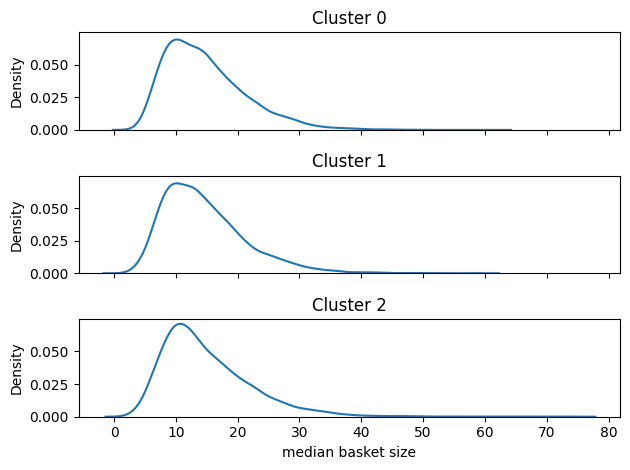

In [84]:
clusters = [0, 1, 2]

fig, axes = plt.subplots(3, 1, sharey=True, sharex=True)

for ax, cluster in zip(axes.flatten(), clusters):
    filtered_data = median_basket_size_per_user.loc[
        median_basket_size_per_user["cluster"] == cluster
    ]
    sns.kdeplot(data=filtered_data["median_basket_size"], ax=ax)
    ax.set_title(f"Cluster {cluster}")

plt.xlabel("median basket size")

plt.tight_layout()

We also examined order timing (day-of-week patterns) and basket size distributions across clusters and found them to be largely similar, suggesting the segments differ primarily in product preferences rather than shopping cadence or volume.

Section 7 addresses strategy (b) from the introduction: cart-based suggestions. Unlike the clustering work above, which characterizes customers based on long-term preference patterns, association rules operate on the basket-in-progress. This makes them especially useful for the cold-start problem (new customers without purchase history that the segmentation can't yet inform), and complementary to the clustering work for established customers. Segmentation informs what a customer might prefer, whereas basket context informs what they may have forgotten right now.

### 7. Association Rules

In [68]:
total_orders = clean_df["order_id"].nunique()
product_support = (
    (
        clean_df.groupby(["product_id", "product_name"])["order_id"].nunique()
        / total_orders
    )
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"order_id": "support"})
)
# product_support
print(
    f"Products with support >= 0.5% are:\n\n {product_support[product_support['support'] >= 0.005]}"
)

Products with support >= 0.5% are:

      product_id                        product_name  support
0         24852                              Banana    0.147
1         13176              Bag of Organic Bananas    0.117
2         21137                Organic Strawberries    0.082
3         21903                Organic Baby Spinach    0.075
4         47209                Organic Hass Avocado    0.066
..          ...                                 ...      ...
244       45603              Trilogy Kombucha Drink    0.005
245       13646                        Lemon Hummus    0.005
246       40174         2% Reduced Fat Organic Milk    0.005
247       21267                     Sourdough Bread    0.005
248       17872  Total 2% Lowfat Plain Greek Yogurt    0.005

[249 rows x 3 columns]


In [69]:
product_id_to_keep = product_support["product_id"].loc[
    product_support["support"] >= 0.005
]
filtered_df_by_support = clean_df[clean_df["product_id"].isin(product_id_to_keep)]
filtered_df_by_support.head()

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,organic
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs,202279,3,5,9,8.000,1
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce,202279,3,5,9,8.000,1
5,2,17794,6,1,Carrots,83,4,fresh vegetables,produce,202279,3,5,9,8.000,0
9,3,33754,1,1,Total 2% with Strawberry Lowfat Greek Strained...,120,16,yogurt,dairy eggs,205970,16,5,17,12.000,0
10,3,24838,2,1,Unsweetened Almondmilk,91,16,soy lactosefree,dairy eggs,205970,16,5,17,12.000,0


In [70]:
orders_to_filter = filtered_df_by_support.groupby("order_id")["product_id"].size()
single_item_order_ids = orders_to_filter[orders_to_filter < 2].index
filtered_data_final = filtered_df_by_support[
    ~filtered_df_by_support["order_id"].isin(single_item_order_ids)
]

Given that there are 49,688 products, if all products are included for running FP-growth algorithm to mine associations, the resulting boolean dataframe is enormous and sparse. Therefore, pre-filtering is performed to popular products only, where a product's support (fraction of orders containing it) is at least 0.5%. We note that only 249 products remain.

Further, given that FP-growth needs co-occurrence to find frequent itemsets of size >= 2, we further filtered out orders containing only one product.

In [71]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

In [72]:
# Create a list of lists, one per order
transactions = (
    filtered_data_final.groupby("order_id")["product_name"].apply(list).tolist()
)

# Encode
te = TransactionEncoder()
te_array = te.fit_transform(transactions)

# Wrap in dataframe with product names as columns
basket_df = pd.DataFrame(te_array, columns=te.columns_)
basket_df

,100% Raw Coconut Water,100% Recycled Paper Towels,100% Whole Wheat Bread,2% Reduced Fat Milk,2% Reduced Fat Organic Milk,Air Chilled Organic Boneless Skinless Chicken Breasts,Apple Honeycrisp Organic,Asparagus,Asparation/Broccolini/Baby Broccoli,Baby Spinach,...,Unsweetened Vanilla Almond Milk,Vanilla Almond Breeze Almond Milk,Vanilla Skyr Nonfat Yogurt,Watermelon Chunks,Whipped Cream Cheese,White Corn,Whole Milk,Yellow Bell Pepper,Yellow Onions,"YoKids Squeezers Organic Low-Fat Yogurt, Strawberry"
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,True,...,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1987618,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1987619,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1987620,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1987621,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [73]:
frequent_itemsets = fpgrowth(basket_df, min_support=0.005, use_colnames=True)

In [74]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

In [75]:
rules[rules["lift"] >= 2.0].sort_values(by="confidence", ascending=False).head(50)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
60,"frozenset({Organic Hass Avocado, Organic Raspb...",frozenset({Bag of Organic Bananas}),0.012,0.171,0.005,0.439,2.568,1.000,0.003,1.478,0.618,0.031,0.323,0.235
47,"frozenset({Organic Hass Avocado, Organic Straw...",frozenset({Bag of Organic Bananas}),0.020,0.171,0.007,0.366,2.139,1.000,0.004,1.307,0.543,0.040,0.235,0.204
40,"frozenset({Organic Hass Avocado, Organic Baby ...",frozenset({Bag of Organic Bananas}),0.017,0.171,0.006,0.345,2.020,1.000,0.003,1.266,0.514,0.032,0.210,0.190
368,frozenset({Lime Sparkling Water}),frozenset({Sparkling Water Grapefruit}),0.022,0.035,0.007,0.302,8.644,1.000,0.006,1.383,0.904,0.131,0.277,0.245
66,"frozenset({Organic Raspberries, Bag of Organic...",frozenset({Organic Strawberries}),0.020,0.125,0.006,0.285,2.285,1.000,0.003,1.224,0.574,0.040,0.183,0.165
353,frozenset({Bunched Cilantro}),frozenset({Limes}),0.022,0.067,0.006,0.284,4.260,1.000,0.005,1.304,0.782,0.075,0.233,0.188
62,"frozenset({Organic Raspberries, Bag of Organic...",frozenset({Organic Hass Avocado}),0.020,0.101,0.005,0.280,2.770,1.000,0.004,1.249,0.652,0.048,0.199,0.167
326,frozenset({Jalapeno Peppers}),frozenset({Limes}),0.020,0.067,0.006,0.275,4.118,1.000,0.004,1.287,0.773,0.068,0.223,0.179
97,frozenset({Organic Cilantro}),frozenset({Limes}),0.033,0.067,0.008,0.258,3.863,1.000,0.006,1.257,0.766,0.093,0.205,0.192
56,frozenset({Organic Raspberries}),frozenset({Organic Strawberries}),0.064,0.125,0.016,0.256,2.049,1.000,0.008,1.176,0.547,0.095,0.150,0.194


From the above, we observed that customers shop in two modes that the rule reflects. The first is meal-assembly based on a recipe's ingredient list, which produces co-occurrences like cilantro + avocado + lime. The second is household restocking that replenishes pantry constants that tend to deplete on similar timelines, which produces co-occurrences like garlic + onion. Both modes are real shopping behaviors, and the algorithm surfaces both.

Further, the fact that, instead of finding spurious co-occurrence between common but unrelated items, the top rules cluster into recognizable behavioral themes (recipes and pantry restocks) is evidence the algorithm is capturing real signal.

The strength of the recipe-driven pattern aligns with Instacart's existing recipe-to-cart feature, which serves as external validation that this type of association mining surfaces real, deployable insights. 

These rules describe historical co-occurrence and serve as a starting point for a cart-suggestion system. Deployed systems typically validate rules with incrementality testing to distinguish which suggestions derive additional purchases from those that merely predict purchases customers would have made regardless. This prioritization matters because suggestion slots are finite and it's crucial to allocate them to the rules that drive incremental behavior.

### Conclusion
For strategy (a) personalized ads: the three-cluster organic-preference segmentation illustrates how organic-preference signals could be used to differentiate sponsored ads. Per-cluster aisle-lift analysis identifies specific over-indexed categories that are particularly valuable for ad targeting.

For strategy (b) cart-based suggestions: the association rules surface frequent co-purchase patterns suitable for checkout-time recommendations. The strongest rules are recipe-driven and pantry-staple complements, which ensures the suggestions will feel intuitive to customers and minimize the 'banner blindness' risk of irrelevant recommendations.

As noted in the Limitations section, this dataset contains notable limitations, including missing prices, user demographics, brand names, and store names.

Given more user and price data, future work could extend to distinguish health-conscious from price-tolerant organic buyers. Incrementality testing would further prioritize rules that drive additional purchases over those that merely predict existing behavior, ensuring finite suggestion slots are allocated to truly incremental recommendations.